<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Proyecto02-Grupo1-Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 2 - Machine Learning

## 1. Portada

**Proyecto:**  Detección de Fraudes Transaccionales

**Programa:** Maestría en Ciencia de Datos & Inteligencia Artificial

**Curso:** MDC8010 - Machine Learning

**Integrantes Grupo 1:**    
- Alejandro Pinedo  
- David Jimenez  
- José Carlos Nomberto

**Fecha de Entrega:** 25 de Marzo, 2026

## 2. Introducción

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de identificar transacciones fraudulentas a partir de un conjunto de datos altamente desbalanceado (aproximadamente 3.5% de fraude). El dataset proporcionado (basado en IEEE-CIS Fraud Detection) contiene cientos de variables continuas y categóricas.

Para abordar este desafío y maximizar el **F1-Score** a estándares industriales, evolucionaremos desde un modelo base lineal hacia estrategias avanzadas de preprocesamiento:
- Implementaremos ingeniería de características temporales y de frecuencia
- Reducción de dimensionalidad (PCA) enfocada en la intrincada colinealidad de las variables *V- features*
- Clustering (MiniBatchKMeans) para la macro-segmentación comportamental
- Construcción de un modelo **LightGBM** (manejando naturalmente el desbalance y la escasez de datos) aplicando Post-Optimización para detectar el umbral exacto de decisión que dispara nuestra recuperación de fraudes sin sacrificar indiscriminadamente la precisión.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
import warnings

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


## 3. Análisis Exploratorio de Datos (EDA)





Cargar y optimizar el uso de memoria de los conjuntos de datos 'train_transaction.csv' y 'train_identity.csv', y luego combinarlos basándose en 'TransactionID'. Posteriormente, realizar un análisis descriptivo inicial del conjunto de datos combinado, incluyendo su forma, tipos de datos, valores nulos, resúmenes estadísticos y el porcentaje de transacciones fraudulentas. Finalmente, trator los datos nulos y aplicar Ingenieria de Caracteristicas.

### 3.1. Carga y Descripción del Dataset



El dataset IEEE-CIS Fraud Detection fue proporcionado por Vesta Corporation y contiene transacciones de comercio electrónico. Se compone de dos archivos:
- train transaction.csv: 590,540 filas × 394 columnas (25.5MB).
- train identity.csv: 144,233 filas × 41 columnas (683.4 MB).

Los archivos se relacionan
mediante la columna TransactionID.

Dado el inmenso tamaño del dataset, cargaremos los datos aplicando una reducción de su huella en memoria, transformando los tipos *float64* e *int64* en alternativas más ligeras como por ejemplo: *float64* a *float32*, *int64* a *int32/int16/int8* según corresponda.

In [2]:
def reduce_mem_usage(df):
    """
    Itera a través de todas las columnas de un dataframe y modifica el tipo de dato
    para reducir el uso de memoria.
    """

    start_mem = df.memory_usage().sum() / 1024**2
    # if verbose:
    #     print(f'Uso de memoria inicial del dataframe: {start_mem:.2f} MB')
    print(f'Uso de memoria inicial del dataframe: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    # if verbose:
    #     print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
    #     print(f'Memoria reducida en: {(100 * (start_mem - end_mem) / start_mem):.2f}%')
    print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
    print(f'Memoria reducida en: {(100 * (start_mem - end_mem) / start_mem):.2f}%')

    return df

print("Función 'reduce_mem_usage' definida.")

Función 'reduce_mem_usage' definida.


Carga y optimización de dataset 'train_transaction.csv'



In [3]:
print("Cargando 'train_transaction.csv' y optimizando su uso de memoria...")
df_train_transaction = pd.read_csv('train_transaction.csv')
df_train_transaction = reduce_mem_usage(df_train_transaction)
print("DataFrame 'df_train_transaction' cargado y optimizado.")
df_train_transaction.head()

Cargando 'train_transaction.csv' y optimizando su uso de memoria...
Uso de memoria inicial del dataframe: 1775.15 MB
Uso de memoria después de la optimización: 487.16 MB
Memoria reducida en: 72.56%
DataFrame 'df_train_transaction' cargado y optimizado.


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

Carga y optimización de dataset 'train_identity.csv'



In [4]:
print("Cargando 'train_identity.csv' y optimizando su uso de memoria...")
df_train_identity = pd.read_csv('train_identity.csv')
df_train_identity = reduce_mem_usage(df_train_identity)
print("DataFrame 'df_train_identity' cargado y optimizado.")
df_train_identity.head()

Cargando 'train_identity.csv' y optimizando su uso de memoria...
Uso de memoria inicial del dataframe: 45.12 MB
Uso de memoria después de la optimización: 10.00 MB
Memoria reducida en: 77.84%
DataFrame 'df_train_identity' cargado y optimizado.


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


Crear el dataset completo uniendo los dos dataset originales con un
LEFT JOIN usando TransactionID

In [5]:
print("Fusionando 'df_train_transaction' y 'df_train_identity' en base a 'TransactionID'...")
df_train = pd.merge(df_train_transaction, df_train_identity, on='TransactionID', how='left')
print(f"DataFrames fusionados. Forma del nuevo DataFrame (df_train): {df_train.shape}")

Fusionando 'df_train_transaction' y 'df_train_identity' en base a 'TransactionID'...
DataFrames fusionados. Forma del nuevo DataFrame (df_train): (590540, 434)


Mostrar cabecera de dataset unificado `df_train`.


In [6]:
print("Mostrando las primeras 5 filas del DataFrame fusionado (df_train):")
display(df_train.head())

Mostrando las primeras 5 filas del DataFrame fusionado (df_train):


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

Mostrar los tipos de datos y los valores no nulos del DataFrame combinado utilizando  para comprender su estructura e identificar posibles problemas.



In [7]:
print("Mostrando información general del DataFrame fusionado (tipos de datos y valores no nulos):")
df_train.info()

Mostrando información general del DataFrame fusionado (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: category(31), float16(354), float32(45), int16(1), int32(2), int8(1)
memory usage: 525.6 MB


Mostrar resumen estadístico de las columnas numéricas para obtener una vista de la distribución de los datos.


In [8]:
print("Mostrando el resumen estadístico de las columnas numéricas de df_train:")
display(df_train.describe())

Mostrando el resumen estadístico de las columnas numéricas de df_train:


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.0,588975.0,586281.0,524834.0,524834.0,238269.0,37627.0,590540.0,590540.0,590540.000000,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,589271.0,309743.0,327662.0,421618.0,280699.0,73187.0,38917.00,74926.000000,74926.000000,514518.0,311253.0,64717.0000,61952.000,62187.000,501427.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,311253.0,514467.0,514467.0,514467.0,514467.00000,514467.000000,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,514467.000000,514467.000000,514467.0,514467.0,514467.0,514467.0,514467.0,514467.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,421571.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,513444.000000,513444.0,513444.0,513444.0,513444.0,513444.0,513444.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.0,501376.000000,501376.0,501376.0,501376.0,501376.0,501376.0,590226.0,590226.0,590226.0,590226.000000,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.0,590226.000000,590226.000000,590226.000000,590226.0,590226.0,590226.0,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,81945.000000,81945.0,81945.0,81945.000000,81945.000000,81951.0,81951.0,81951.0,81945.000000,81945.000000,81945.000000,81945.00000,81951.0,81951.0,81951.0,81945.000000,81945.000000,81945.000000,81945.000000,81945.0,81945.0,81951.0,81951.000000,81945.0,81945.0,81945.0,81951.000000,81951.000000,81951.000000,139631.0,139631.0,139819.0,139819.0,139819.0,1

### 3.2. Estadísticas descriptivas, distribuciones y visualizaciones


#### Separar Características por Tipo

Identificar y clasificar las columnas del DataFrame en numéricas y categóricas para facilitar un análisis y visualización estructurados, excluyendo 'TransactionID' e 'isFraud' para la clasificación inicial.


In [9]:
print("Clasificando columnas en numéricas y categóricas...")
numerical_cols = []
categorical_cols = []

# Excluir 'TransactionID' y 'isFraud' de la clasificación
excluded_cols = ['TransactionID', 'isFraud']

for col in df_train.columns:
    if col in excluded_cols:
        continue
    if df_train[col].dtype == 'object' or df_train[col].dtype == 'category':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print(f"Total de columnas numéricas encontradas: {len(numerical_cols)}")
print(f"Primeras 5 columnas numéricas: {numerical_cols[:5]}")
print(f"Total de columnas categóricas encontradas: {len(categorical_cols)}")
print(f"Primeras 5 columnas categóricas: {categorical_cols[:5]}")

Clasificando columnas en numéricas y categóricas...
Total de columnas numéricas encontradas: 401
Primeras 5 columnas numéricas: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3']
Total de columnas categóricas encontradas: 31
Primeras 5 columnas categóricas: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


#### Visualizar distribución de variable objetico 'isFraud'

Mostrar y validar el porcentaje de transacciones fraudulentas.



In [10]:
print("Calculando el porcentaje de transacciones fraudulentas:")
fraud_percentage = (df_train['isFraud'].sum() / len(df_train)) * 100
print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.2f}%")

Calculando el porcentaje de transacciones fraudulentas:
Porcentaje de transacciones fraudulentas: 3.50%




Generar un gráfico de barras para visualizar la distribución de la variable objetivo 'isFraud', confirmando el desbalance de clases y documentando el porcentaje de cada clase. Incluirá la visualización del porcentaje de transacciones fraudulentas.


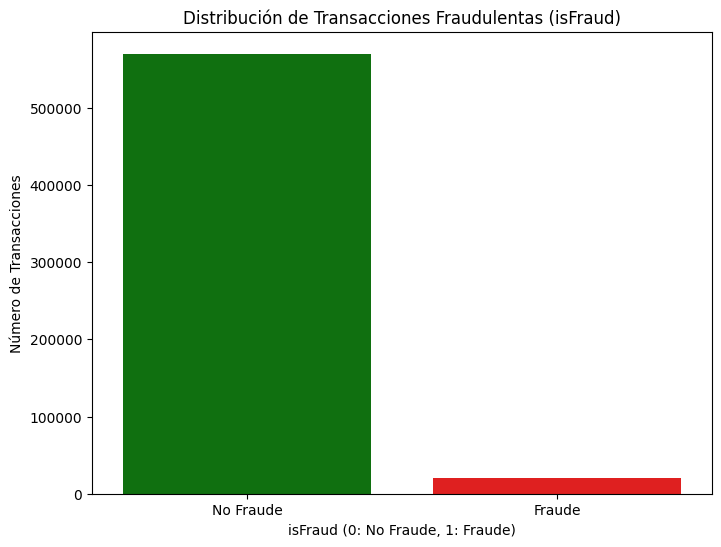

Porcentaje de transacciones fraudulentas: 3.50%


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='isFraud', data=df_train, hue='isFraud', palette=custom_palette, legend=False)
plt.title('Distribución de Transacciones Fraudulentas (isFraud)')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('Número de Transacciones')
plt.xticks([0, 1], ['No Fraude', 'Fraude'])
plt.show()

print(f"Porcentaje de transacciones fraudulentas: {fraud_percentage:.2f}%")

#### Visualizar distribución de Características Numéricas Clave

Visualizar la distribución de características numéricas importantes como 'TransactionAmt' y 'TransactionDT' mediante histogramas o gráficos de densidad. Además, se explorará cómo estas distribuciones varían entre transacciones fraudulentas y no fraudulentas usando gráficos de violín o box plots.


Visualización de la distribución de 'TransactionAmt

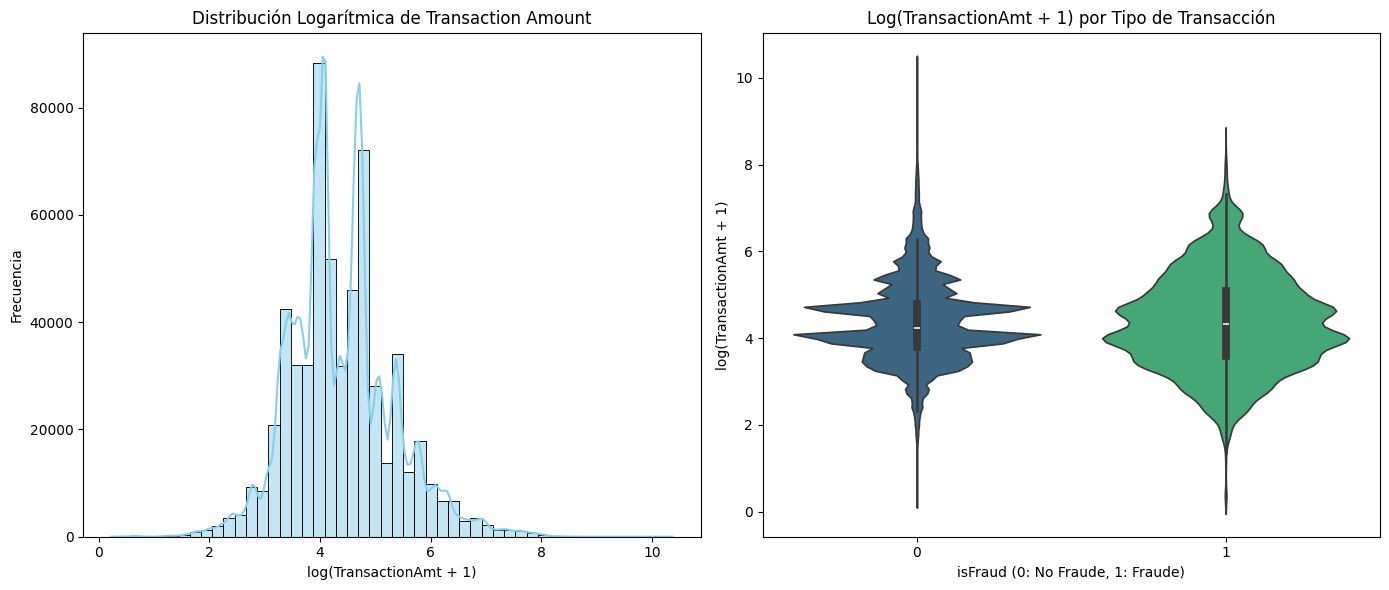

In [12]:
# Visualización para 'TransactionAmt'
plt.figure(figsize=(14, 6))

# Histograma de TransactionAmt (con transformación logarítmica para mejor visualización)
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df_train['TransactionAmt']), bins=50, kde=True, color='skyblue')
plt.title('Distribución Logarítmica de Transaction Amount')
plt.xlabel('log(TransactionAmt + 1)')
plt.ylabel('Frecuencia')

# Violin plot de TransactionAmt vs isFraud
plt.subplot(1, 2, 2)
sns.violinplot(x='isFraud', y=np.log1p(df_train['TransactionAmt']), data=df_train, palette='viridis')
plt.title('Log(TransactionAmt + 1) por Tipo de Transacción')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('log(TransactionAmt + 1)')
plt.tight_layout()
plt.show()

Visualización de la distribución de 'TransactionDT

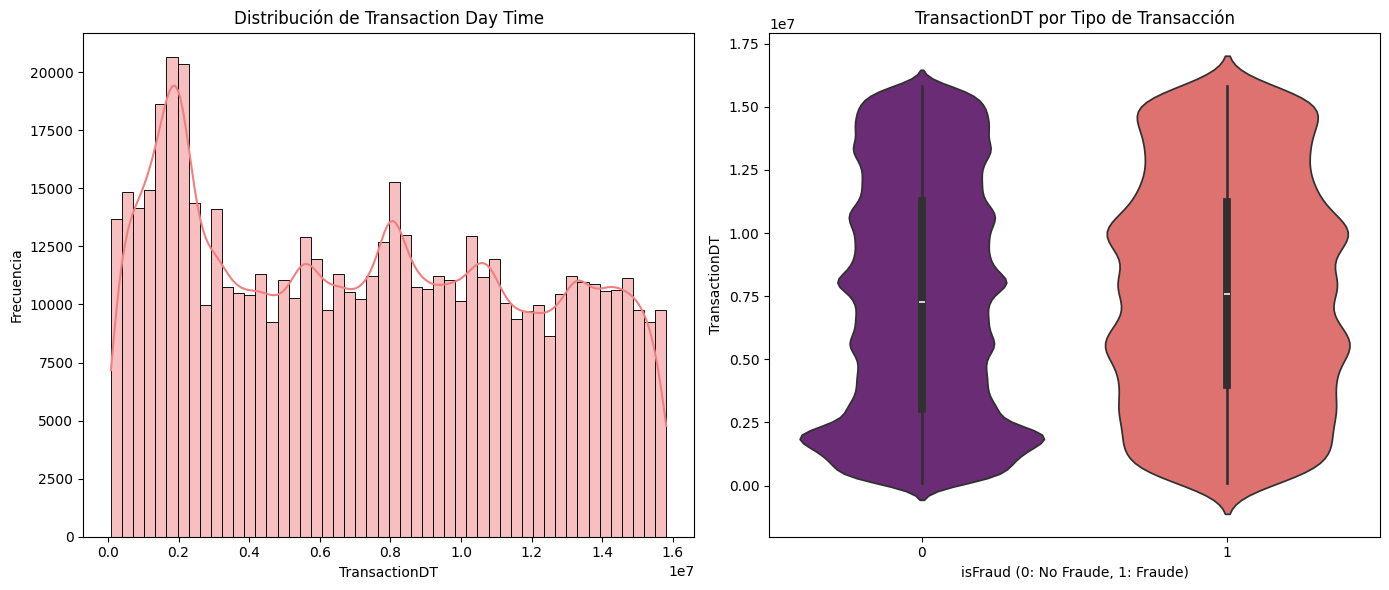

In [13]:
# Visualización para 'TransactionDT'
plt.figure(figsize=(14, 6))

# Histograma de TransactionDT
plt.subplot(1, 2, 1)
sns.histplot(df_train['TransactionDT'], bins=50, kde=True, color='lightcoral')
plt.title('Distribución de Transaction Day Time')
plt.xlabel('TransactionDT')
plt.ylabel('Frecuencia')

# Violin plot de TransactionDT vs isFraud
plt.subplot(1, 2, 2)
sns.violinplot(x='isFraud', y=df_train['TransactionDT'], data=df_train, hue='isFraud', palette='magma', legend=False)
plt.title('TransactionDT por Tipo de Transacción')
plt.xlabel('isFraud (0: No Fraude, 1: Fraude)')
plt.ylabel('TransactionDT')
plt.tight_layout()
plt.show()

#### Distribución de Características Categóricas Clave

Crear gráficos de barras para las características categóricas relevantes como 'ProductCD', 'card4', 'card6' y 'M4' para observar sus distribuciones por categoría, diferenciando por 'isFraud' para entender los patrones de fraude.

Visualizando la distribución de 'ProductCD' por 'isFraud'

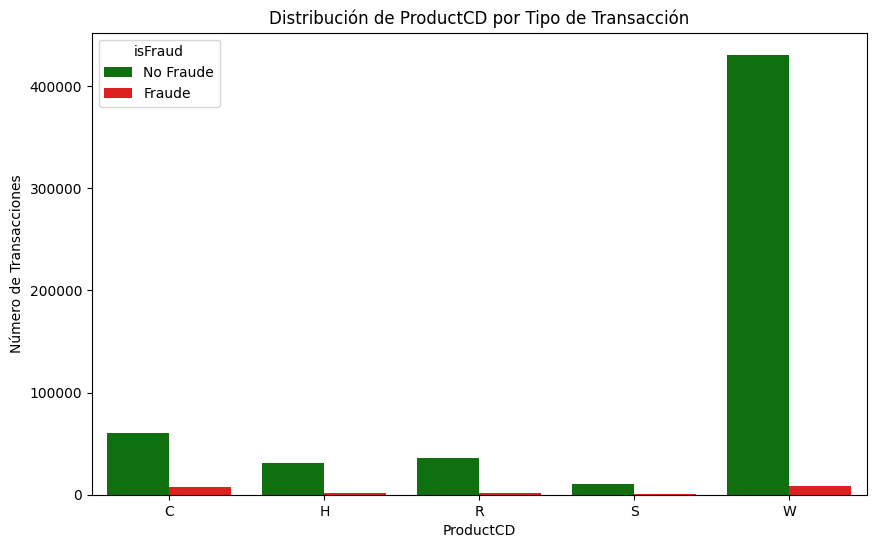

In [14]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='ProductCD', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de ProductCD por Tipo de Transacción')
plt.xlabel('ProductCD')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'card4' por 'isFraud'.



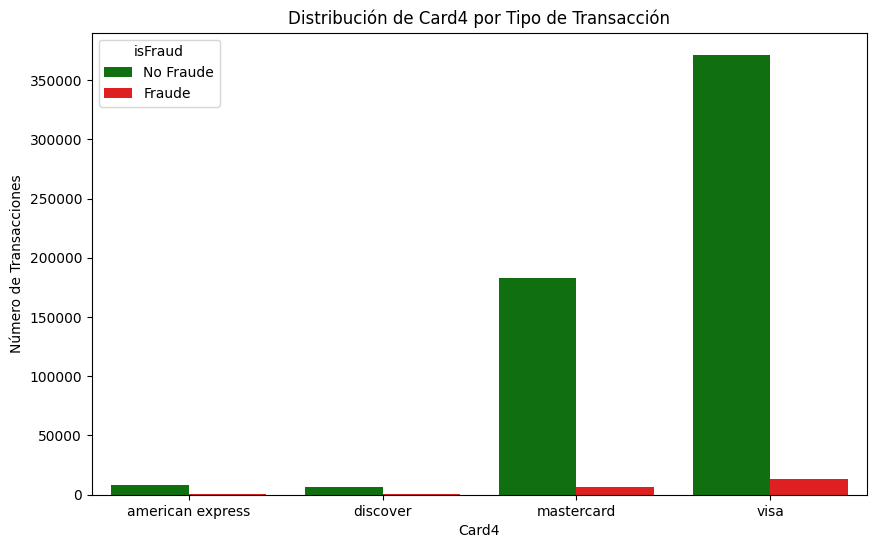

In [15]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='card4', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de Card4 por Tipo de Transacción')
plt.xlabel('Card4')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'card6' por 'isFraud'.




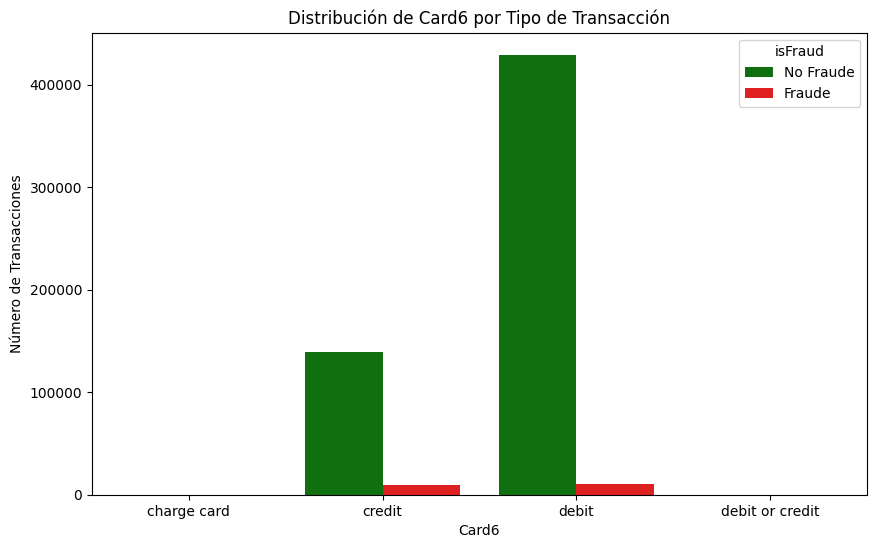

In [16]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='card6', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de Card6 por Tipo de Transacción')
plt.xlabel('Card6')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

Visualizando la distribución de 'M4' por 'isFraud'.




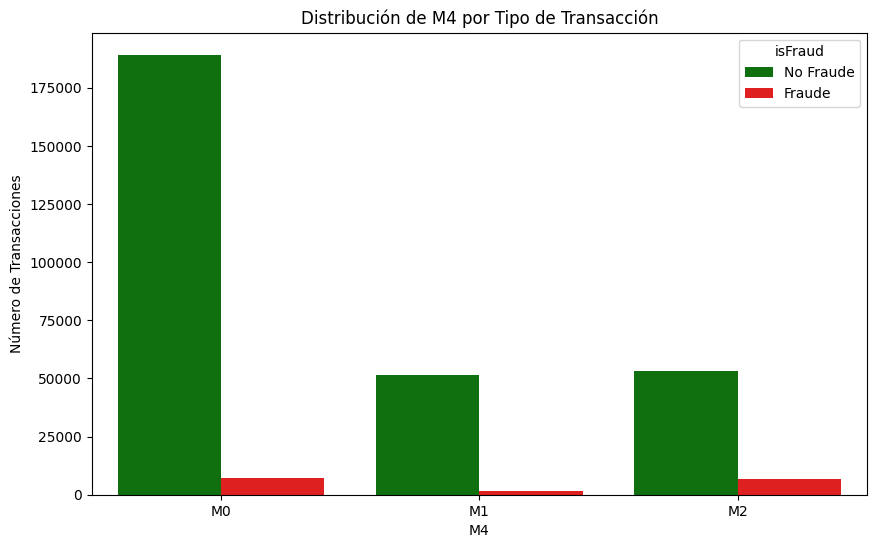

In [17]:
plt.figure(figsize=(10, 6))
custom_palette = {0: 'green', 1: 'red'}
sns.countplot(x='M4', hue='isFraud', data=df_train, palette=custom_palette)
plt.title('Distribución de M4 por Tipo de Transacción')
plt.xlabel('M4')
plt.ylabel('Número de Transacciones')
plt.legend(title='isFraud', labels=['No Fraude', 'Fraude'])
plt.show()

#### Matriz de Correlación

Calcular y visualizar una matriz de correlación para las características numéricas, incluyendo la variable objetivo 'isFraud', para identificar posibles relaciones lineales entre las variables y con el fraude.

**NOTA** Debido al número de variables, es dificil mostrar la relación entre variables graficamente. Por ello se calcula la matriz de correlación, para visualizar luego la distribución de la correlación.

In [18]:
# Seleccionar solo las columnas numéricas y 'isFraud'
numerical_features_with_fraud = numerical_cols + ['isFraud']
df_numerical = df_train[numerical_features_with_fraud]

# Calcular la matriz de correlación
correlation_matrix = df_numerical.corr()

# Extraer las correlaciones con la columna 'isFraud'
isFraud_correlation = correlation_matrix['isFraud'].sort_values(ascending=False)
index_isFraud_correlation = isFraud_correlation.index.tolist()

# Calcular la matriz de correlación ordenada con isFraud
correlation_matrix_sorted = df_numerical[index_isFraud_correlation].corr()

# Crear un gráfico de mapa de calor
#plt.figure(figsize=(12, 8))
#sns.heatmap(matriz_correlacion_ordenada, annot=True, annot_kws={"fontsize": 8}, cmap='coolwarm', fmt=".2f", linewidths=.5)
#plt.title('Matriz de Correlación de variables correlacionadas con isFraud')
#plt.show()
#plt.figure(figsize=(20, 18))
#sns.heatmap(correlation_matrix_sorted, cmap='coolwarm', fmt=".2f", linewidths=.05)
#plt.title('Matriz de Correlación de Características Numéricas e isFraud')
#plt.show()

Visualizar la distribución de Correlacion con isFraud

Text(0, 0.5, 'Frecuencia')

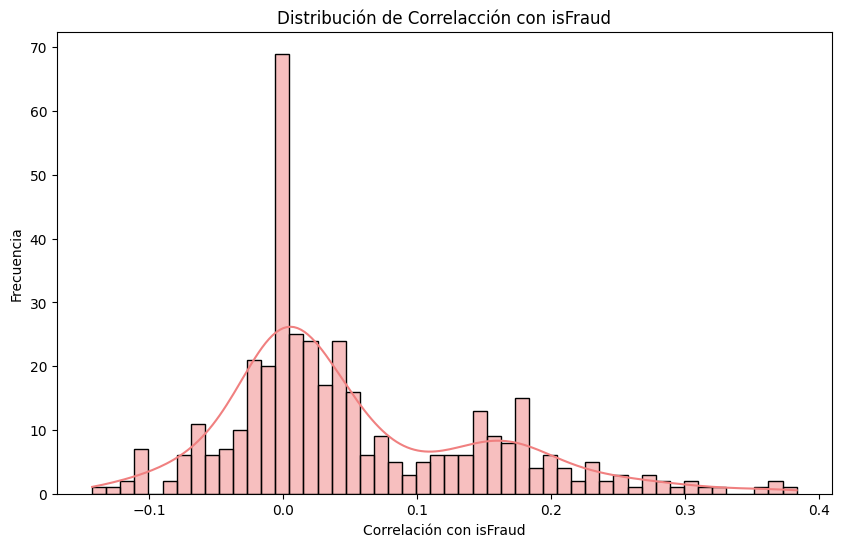

In [19]:
# Histograma de Correlacion con isFraud
plt.figure(figsize=(10, 6))
sns.histplot(isFraud_correlation.drop('isFraud'), bins=50, kde=True, color='lightcoral')
plt.title('Distribución de Correlacción con isFraud')
plt.xlabel('Correlación con isFraud')
plt.ylabel('Frecuencia')


In [20]:
isFraud_correlation.drop('isFraud').head(20)

,isFraud
V257,0.383060
V246,0.366878
V244,0.364129
V242,0.360590
V201,0.328005
V200,0.318783
V189,0.308219
V188,0.303582
V258,0.297151
V45,0.281832


Se observa que los valores de correlación de las variables con la variable objetivo isFraud son menores a 0.38. Esto indica que no existe una sola variable que explique el fraude por sí sola de forma lineal, sino como la combinación de múltiples factores, ya que cada variable aporta información al modelo.

### 3.3. Tratamiento de Valores Faltantes y Atípicos



Calcular y mostrar el porcentaje de valores nulos para cada columna en el DataFrame combinado `df_train`, ordenándolos de forma descendente para identificar rápidamente las columnas con información faltante significativa.



In [21]:
print("Calculando el porcentaje de valores nulos por columna en df_train:")
missing_values = df_train.isnull().sum()
missing_percent = 100 * missing_values / len(df_train)
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print(f"Cantidad de variables con Missing_Percentage > 80: {len(missing_df[missing_df['Missing Count'] > 80])}")
print("Top 20 variables con mayor Missing_Percentage")
display(missing_df.head(20))


Calculando el porcentaje de valores nulos por columna en df_train:
Cantidad de variables con Missing_Percentage > 80: 382
Top 20 variables con mayor Missing_Percentage


,Missing Count,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_23,585371,99.124699
id_22,585371,99.124699
id_27,585371,99.124699
dist2,552913,93.628374


Se realiza el tratamiento de valores faltantes con las siguientes consideraciones:
* Columnas desérticas (> 80% nulos) son eliminadas enteramente ya que proveen ruido inútil.
* Para el resto de columnas, **dejaremos los nulos (`NaN`) intactos.** *LightGBM* posee rutinas optimizadas ('*Sparse Distribution Tracking*') que evalúan de manera automática en qué nodo direccionar los valores nulos para maximizar la disminución de entropía. Inyectar medias o medianas arbitrarias a menudo oscurece esta potente característica latente de ausencia.

In [22]:
import gc

missing_threshold = 80
high_missing_cols = missing_df[missing_df['Missing Percentage'] > missing_threshold].index.tolist()

# Crear un DataFrame booleano para los valores nulos de estas columnas
df_high_missing_nulls = df_train[high_missing_cols].isnull()
df_train.drop(columns=high_missing_cols, inplace=True)
print(f"Se descartaron {len(high_missing_cols)} columnas (por contener >80% valores nulos).")
gc.collect()

Se descartaron 74 columnas (por contener >80% valores nulos).


9957

### 3.4. Feature Engineering




**Transformación Logarítmica**

Aplicamos un logaritmo a las transacciones TransactionAmt para suavizar sus extremos exponenciales.

In [23]:
# Transformación Logarítmica
df_train['TransactionAmt_Log'] = np.log1p(df_train['TransactionAmt'])

**Agregaciones de Grupo**

Calculamos la varianza transaccional de un usuario respecto de su historial agrupando mediante características del medio de pago (card1). La desviación frente a esa media ayuda a capturar picos anómalos.

In [24]:
card_amt_mean = df_train.groupby('card1')['TransactionAmt'].mean().to_dict()
df_train['Card1_Amt_Mean'] = df_train['card1'].map(card_amt_mean)
# Desviación estandarizada relacional:
df_train['Card1_Amt_Std_Dev'] = df_train['TransactionAmt'] / df_train['Card1_Amt_Mean']

**Caracteristicas temporales**

Extraer nuevas características temporales de la columna 'TransactionDT', como la hora del día, el día de la semana y el día del mes. Esto ayudará a capturar patrones cíclicos y tendencias que podrían estar relacionados con el fraude.

In [25]:
print("Creando características temporales a partir de 'TransactionDT'...")

# Convertir TransactionDT a timedelta y luego a datetime
df_train['TransactionDT_datetime'] = pd.to_datetime('2018-01-01') + pd.to_timedelta(df_train['TransactionDT'], unit='s')

# Extraer la hora del día
df_train['TransactionDT_hour'] = df_train['TransactionDT_datetime'].dt.hour.astype(np.int8)

# Extraer el día de la semana (Lunes=0, Domingo=6)
df_train['TransactionDT_day_of_week'] = df_train['TransactionDT_datetime'].dt.dayofweek.astype(np.int8)

# Extraer el día del mes
df_train['TransactionDT_day_of_month'] = df_train['TransactionDT_datetime'].dt.day.astype(np.int8)

print("Características temporales creadas exitosamente.")
print("Primeras 5 filas con las nuevas características:")
display(df_train[['TransactionDT', 'TransactionDT_datetime', 'TransactionDT_hour', 'TransactionDT_day_of_week', 'TransactionDT_day_of_month']].head())

Creando características temporales a partir de 'TransactionDT'...
Características temporales creadas exitosamente.
Primeras 5 filas con las nuevas características:


,TransactionDT,TransactionDT_datetime,TransactionDT_hour,TransactionDT_day_of_week,TransactionDT_day_of_month
0,86400,2018-01-02 00:00:00,0,1,2
1,86401,2018-01-02 00:00:01,0,1,2
2,86469,2018-01-02 00:01:09,0,1,2
3,86499,2018-01-02 00:01:39,0,1,2
4,86506,2018-01-02 00:01:46,0,1,2


**Características de Frecuencia**


Generar características basadas en la frecuencia de ocurrencia para columnas categóricas y numéricas clave con alta cardinalidad (por ejemplo, 'cardX', 'addr1', 'P_emaildomain', 'ProductCD'). Las frecuencias relativas pueden ser indicativas de comportamientos anómalos o de grupos específicos de fraude.


In [26]:
# Frequency Encoding (Codificación por distribución acumulada)
categorical_features = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in categorical_features:
    if col in df_train.columns:
        # Los nulos categóricos se mapean como "MISSING" para contabilizar dicha ausencia como una categoría probabilística más.
        df_train[col] = df_train[col].astype(str).fillna('MISSING')
        freq = df_train[col].value_counts(normalize=True).to_dict()
        df_train[col + '_Freq'] = df_train[col].map(freq)
        df_train.drop(columns=[col], inplace=True)


### Resumen de Hallazgos de EDA


**Observaciones:**

*   **Desbalance de Clase:** Se confirma un desbalance significativo en la variable objetivo `isFraud`, con un 3.50% de transacciones fraudulentas.

*   **`TransactionAmt`:** Las transacciones fraudulentas tienden a tener montos más altos o distribuciones bimodales en comparación con las no fraudulentas, como se observó en los violin plots logarítmicos. Esto sugiere que el monto de la transacción es un indicador importante de fraude.

*   **`TransactionDT`:** La distribución de `TransactionDT` (tiempo de la transacción) muestra diferencias entre transacciones fraudulentas y no fraudulentas, indicando posibles patrones temporales en la ocurrencia de fraude. Podría ser relevante extraer características de tiempo como día de la semana o hora del día.

*   **Características Categóricas:**
    *   `ProductCD`: Se observaron diferencias notables en las distribuciones de fraude entre las distintas categorías de `ProductCD`. Por ejemplo, la categoría 'W' tiene un volumen mucho mayor de transacciones no fraudulentas, mientras que otras categorías podrían tener una proporción de fraude más alta.
    *   `card4` y `card6`: Las distribuciones de tipos de tarjeta (`card4`: VISA, Mastercard, American Express, Discover y `card6`: crédito/débito) también muestran variaciones en la proporción de fraude, lo que sugiere que ciertos emisores o tipos de tarjeta podrían ser más susceptibles al fraude.
    *   `M4`: La variable `M4` también exhibe patrones distintos de fraude entre sus categorías, lo que podría ser útil en la detección.

*   **Valores Nulos:** El análisis de valores nulos reveló que una gran cantidad de columnas, particularmente las variables `id_xx` (relacionadas con la identidad del comprador) y algunas `V-features` y `D-features`, tienen un porcentaje muy alto de datos faltantes (más del 50%, y en algunos casos, más del 90%). Esto es crítico, por lo que para evitar este ruido, se eliminan las columnas con %nulos > 80. LightGBM maneja adecuadamente los valores nulos, por lo que no se realiza imputación de los remanentes.

*   **Correlación:** La matriz de correlación muestra que la mayoría de las características numéricas tienen correlaciones bajas con `isFraud`. Sin embargo, existen intercorrelaciones significativas entre muchas de las variables `V-features` y `C-features`, lo que justifica la estrategia de reducción de dimensionalidad para manejar la colinealidad. Algunas variables, aunque con baja correlación lineal, podrían tener relaciones no lineales importantes que un modelo como LightGBM puede capturar.

## 4. Reducción de Dimensionalidad


### 4.1 Selección y justificación

Debido a que el dataset de IEEE-CIS tiene cientos de columnas (especialmente las variables "V"), la reducción de dimensionalidad ayuda a:

- Eliminar la redundancia: Muchas variables están altamente correlacionadas entre sí.

- Reducir el ruido: Filtra variaciones pequeñas que no aportan al patrón general.

- Mejorar el Clustering:  Reducir las dimensiones hace que las distancias sean más significativas, y evita sufrir la "maldición de la dimensionalidad".

PCA es elegido sobre otros métodos de reducción de dimensionalidad como t-SNE o UMAP por las siguientes razones:
- Preservación de la Estructura Global: ya que busca maximizar la varianza global. En fraude, nos interesan las grandes desviaciones. t-SNE y UMAP se enfocan en preservar la estructura local (vecinos cercanos), lo que puede "inventar" agrupaciones que no existen o ignorar la escala global de los montos de transacciones.
- Determinismo y Predictibilidad: al ser una transformación lineal exacta, para una nueva transacción, es posible proyectarla al espacio de PCA usando los mismos coeficientes. A diferencia de t-SNE que no permite transformar datos nuevos y UMAP, aunque lo soporta, no es deterministico.
- Costo Computacional: Tienes un dataset con cientos de columnas "V" y miles de filas. PCA es extremadamente rápido (basado en álgebra lineal). t-SNE tiene una complejidad cuadrática $O(N^2)$, lo que lo hace prohibitivo para datasets de este tamaño sin un submuestreo agresivo
- Interpretabilidad de la Varianza: se puede explicar un porcentaje de la varianza de datos con una cantidad especifica de componentes. UMAP o t-SNE, no tienen una métrica clara de cuánta información se conserva o se perdió.

#### Preprocesar los datos para PCA



El preprocesamiento para PCA incluye:
- Identificar las V-features, para  manejar la colinealidad.
- Imputar valores nulos utilizando una estrategia de 'mediana'
- Escalar los V-features imputados utilizando `StandardScaler` lo cual es un paso de preprocesamiento crucial para el PCA.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Identificar todas las columnas que comienzan con 'V'
print("Identificando y separando las 'V-features' para PCA ...")
#v_cols = [c for c in df.columns if c.startswith('V')]
v_features_cols = [col for col in df_train.columns if col.startswith('V')]
print(f"Cantidad de V-features identificadas: {len(v_features_cols)}")

# Crear dataframe con solo las columnas que comienzan con 'V'
df_v_features = df_train[v_features_cols].copy()

# Imputar puramente local para PCA (el df original los mantiene)
print("Imputando valores nulos en df_v_features_pca con la mediana ...")
df_v_features.fillna(df_v_features.median(), inplace=True)
# Instanciar SimpleImputer con estrategia 'median'
# imputer = SimpleImputer(strategy='median')

# Escalar estandarizado
print("Escalando df_v_features_pca_imputed con StandardScaler ...")
scaler = StandardScaler()
df_v_scaled = scaler.fit_transform(df_v_features)
print("Pre-procesamiento para PCA concluido")

Identificando y separando las 'V-features' para PCA ...
Cantidad de V-features identificadas: 292
Imputando valores nulos en df_v_features_pca con la mediana ...
Escalando df_v_features_pca_imputed con StandardScaler ...
Pre-procesamiento para PCA concluido


#### Aplicar PCA

Aplicar PCA para reducir su dimensionalidad, utilizando los 15 primeros componentes principales que expliquen la varianza.



In [28]:
# Aplicar PCA
print("Aplicando PCA a las V-features escaladas e imputadas ...")
pca = PCA(n_components=15, random_state=42)
v_pca = pca.fit_transform(df_v_scaled)

print(f"Forma de los componentes de PCA: {v_pca.shape}")
print(f"Varianza explicada por los componentes seleccionados: {pca.explained_variance_ratio_.sum():.2f}")
print("Aplicación de PCA a V-features completada.")

Aplicando PCA a las V-features escaladas e imputadas ...
Forma de los componentes de PCA: (590540, 15)
Varianza explicada por los componentes seleccionados: 0.66
Aplicación de PCA a V-features completada.


#### Explorar la varianza explicada

Graficar la Varianza Explicada acumulada vs el número de componentes principales. Con 15 componentes, se explica el 66% de la varianza.


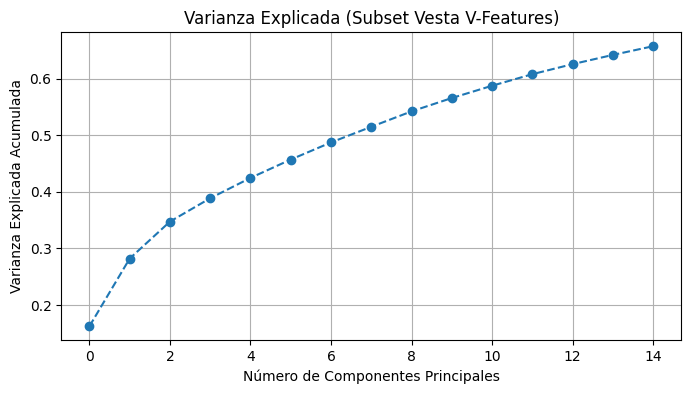

In [29]:
# Exploración visual de varianza explicada
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada (Subset Vesta V-Features)')
plt.grid()
plt.show()

#### Depuración de dataframe

Eliminar la columnas V-features y agregar las componentes PCA encontradas


In [30]:
# Eliminación de las V-columns puras
df_train.drop(columns=v_features_cols, inplace=True)

# Agregar componentes PCA al dataframe
for i in range(15):
    df_train[f'V_PCA_{i+1}'] = v_pca[:, i]

print(f"Dimensionalidad destruida. Reducidas {len(v_features_cols)} columnas 'V' ruidosas en {15} componentes limpios (PCA).")

del df_v_features, df_v_scaled, v_pca
gc.collect()

Dimensionalidad destruida. Reducidas 292 columnas 'V' ruidosas en 15 componentes limpios (PCA).


27091

### 4.2 Visualización del espacio reducido

#### Visualizar el Espacio Reducido (Primeros 2 Componentes PCA)

Generar un gráfico de dispersión utilizando los dos primeros componentes principales, coloreando los puntos según el valor de 'isFraud' para observar la separación de clases, utilizando una muestra aleatoria de los datos.


Generando un gráfico de dispersión de los dos primeros componentes PCA...


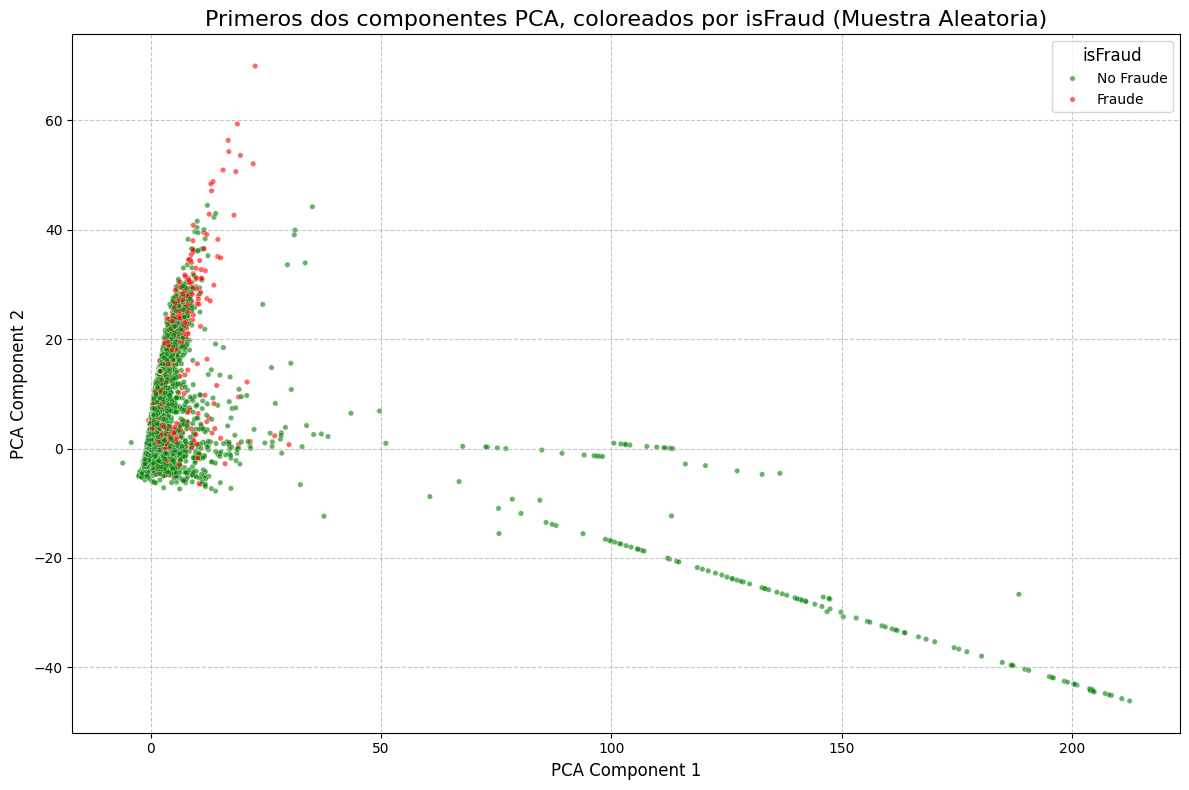

Visualización del espacio reducido PCA completada.


In [31]:
print("Generando un gráfico de dispersión de los dos primeros componentes PCA...")

# Definir un tamaño de muestra y tomar una muestra aleatoria
sample_size = 50000 # Un tamaño de muestra adecuado para visualizar la densidad
df_pca_sample = df_train.sample(n=sample_size, random_state=42)

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='V_PCA_1',
    y='V_PCA_2',
    hue='isFraud',
    data=df_pca_sample,
    palette={0: 'green', 1: 'red'},
    alpha=0.6,
    s=15 # Tamaño de los puntos
)
plt.title('Primeros dos componentes PCA, coloreados por isFraud (Muestra Aleatoria)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['No Fraude', 'Fraude'], title='isFraud', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualización del espacio reducido PCA completada.")

El diagrama de dispersión, utilizando los dos primeros componentes PCA, coloreados según la variable 'isFraud', muestra una superposición entre las clases 'Fraude' (puntos rojos) y 'No Fraude' (puntos verdes). Esto sugiere que los dos primeros componentes principales por sí solos no proporcionan una separación lineal clara entre las transacciones fraudulentas y las no fraudulentas. Los casos de fraude (puntos rojos) están dispersos y parecen estar integrados en el grupo más grande de casos no fraudulentos (puntos verdes), lo que indica que no son fácilmente distinguibles en esta representación PCA bidimensional.

### 4.3 Evaluación del impacto en el desempeño del modelo

La reducción de dimensionalidad impacta en el modelo debido a que:

- Selecciona el número de componentes que explican el 66% de la varianza para reducir la dimensionalidad de ~300 a 15 variables, eliminando el ruido pero reteniendo la información esencial.

- En combinación con clustering, captura estructuras latentes de comportamiento transaccional que las variables originales por separado no muestran, lo cual permite a los modelos de clasificación entender el 'contexto' de la transacción.

- El uso de escalado evita que el sesgo hacia las variables con números más grandes.

### Conclusiones

* Dada la superposición, los dos primeros componentes del PCA no son suficientes para una separación visual o lineal clara entre transacciones fraudulentas y no fraudulentas. Un análisis posterior podría implicar la exploración de componentes adicionales del PCA u otras técnicas de reducción de dimensionalidad para lograr una mejor separación de clases.

* Este hallazgo confirma el uso de modelos de clasificación sofisticados que puedan manejar relaciones no lineales o conjuntos de datos altamente desequilibrados, ya que es poco probable que los modelos lineales simples basados ​​en estos dos primeros componentes del PCA tengan un buen rendimiento.

## 5. Clustering



### 5.1 Selección y justificación de algoritmo

Para el Clustering, se ha elegido MiniBatchKmeans, ya que a diferencia del K-Means tradicional, que necesita procesar todos los puntos de datos en cada iteración para recalcular los centroides,  utiliza pequeños subconjuntos (batches) de datos elegidos al azar.

MiniBatchKMeans reduce drásticamente el tiempo de cómputo con una pérdida mínima en la calidad de los clusters, sobretodo para datasets de gran tamaño como train_transaction.csv es masivo, donde el K-Means estándar podría agotar la memoria RAM o tardar demasiado tiempo.

En comparación con DBSCAN que tiene una complejidad de O(N**2), MiniBatchKMeans tiene una complejidad menor O(N), que hace que sea apropiado para datasets de gran tamaño. En el caso del Clustering Jerárquico, el calculo de la matriz de distancias completa, hace que no escale a datasets de gran tamaño.

#### Preprocesamiento para Clustering



Aplicar el algoritmo MiniBatchKMeans sobre un subconjunto de características numéricas relevantes para crear segmentos comportamentales. Los resultados de este clustering se añadirán como nuevas características al dataset, proporcionando una macro-segmentación que puede revelar patrones de fraude.


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.impute import SimpleImputer
import numpy as np

# Identificar variables para agrupamiento
# Se seleccionan TransactionAmt, C-features, D-features, y los V_PCA features que mostraron correlación o relevancia en el EDA.

# Definir regex
# c_pattern = r'^C\d'
# d_pattern = r'^D\d'
v_pattern =r'^V_PCA_([1-9]|1[0-5])$'
# Filtrar las columnas
#c_features = df_train.columns[df_train.columns.str.match(c_pattern)].tolist()
#d_features = df_train.columns[df_train.columns.str.match(d_pattern)].tolist()
v_features = df_train.columns[df_train.columns.str.match(v_pattern)].tolist()

# clustering_features = ['TransactionAmt'] + c_features + d_features + v_features
clustering_features = ['TransactionAmt', 'LogTransactionAmt', 'Transaction_Hour'] + v_features

# Filtrar solo las columnas que existen en df_train para evitar errores
clustering_features = [col for col in clustering_features if col in df_train.columns]

# Crear Dataframe para clustering
df_clustering = df_train[clustering_features].copy()

# Imputar valores nulos usando la mediana para robustez contra outliers
imputer = SimpleImputer(strategy='median')
df_clustering_imputed = imputer.fit_transform(df_clustering)

# Escalar las características
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering_imputed)

print(f"Dimensiones de las características para clustering después de imputación y escalado: {df_clustering_scaled.shape}")


Dimensiones de las características para clustering después de imputación y escalado: (590540, 16)


### 5.2 Determinación del número óptimo de clusters

#### Método del Codo

Se utiliza el método del codo (`Elbow Method`) para calcular el valor óptimo de número de clusters . Se calcula la inercia (suma de cuadrados dentro del cluster) para un rango de valores de 'k' (número de clusters) y se visualiza la curva resultante para identificar el 'codo', que indica el punto de disminución marginal en la inercia.

Ejecutando el Método del Codo para determinar el número óptimo de clusters...


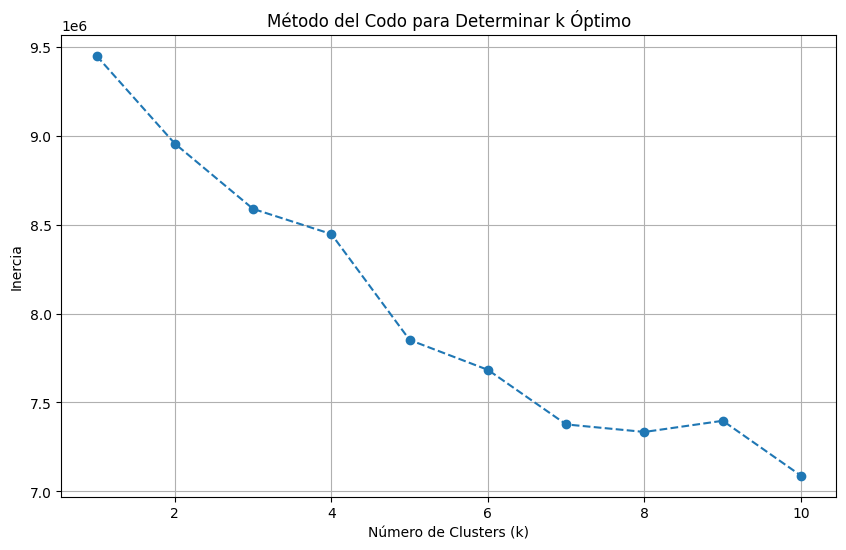

Análisis del Método del Codo completado. Examine el gráfico para identificar el codo.


In [33]:
print("Ejecutando el Método del Codo para determinar el número óptimo de clusters...")

# Definir un rango de k valores
k_range = range(1, 11) # Evaluar de 1 a 10 clusters

# Inicializar lista para almacenar los valores de inercia
inertia = []

# Loop a través del rango de k valores
for k in k_range:
    # a. Crear una instancia de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10, verbose=False)

    # b. Ajustar el modelo a los datos escalados
    mbkmeans.fit(df_clustering_scaled)

    # c. Añadir la inercia del modelo a la lista
    inertia.append(mbkmeans.inertia_)

# Plotear los k valores contra sus valores de inercia
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Método del Codo para Determinar k Óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

print("Análisis del Método del Codo completado. Examine el gráfico para identificar el codo.")

#### Método de Coeficientes de Silhouette

Calcular el coeficiente de silueta (Silhouette Score) para un rango de valores de 'k' para evaluar la calidad de los clusters. Un valor más cercano a 1 indica clusters bien separados y densos. Se visualizarán los resultados para identificar el número de clusters que maximiza este coeficiente. Para acelerar el proceso, se utilizará una muestra aleatoria del dataset `df_clustering_scaled` (aprox. 10%).


Ejecutando el Método de la Silueta para determinar el número óptimo de clusters (con muestreo)...


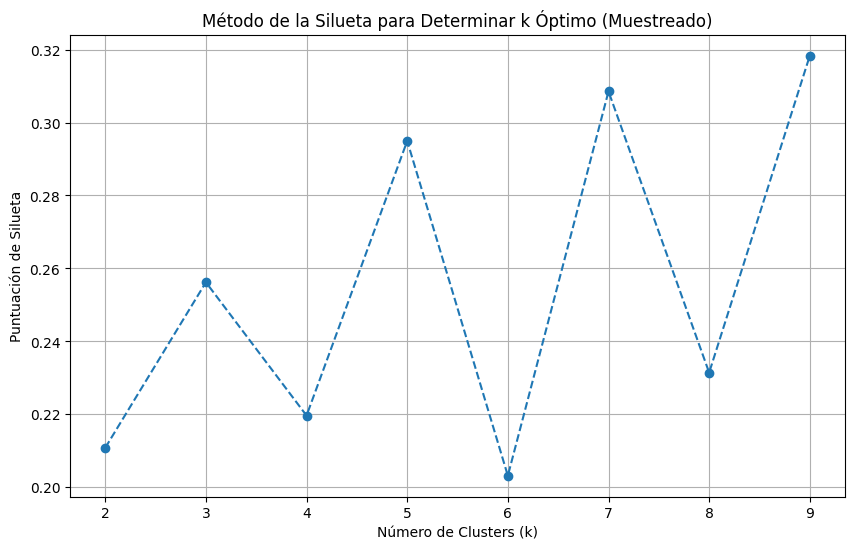

Análisis del Método de la Silueta completado. Examine el gráfico para identificar el k con la puntuación más alta.


In [34]:
print("Ejecutando el Método de la Silueta para determinar el número óptimo de clusters (con muestreo)...")

from sklearn.metrics import silhouette_score

# Definir un rango de valores para k (Silhouette Score no está definido para k=1)
k_range_silhouette = range(2, 10) # Evaluar de 2 a 10 clusters

# Inicializar lista para almacenar los valores de silhouette score
silhouette_scores = []

# Definir el tamaño de la muestra para el cálculo de Silhouette Score (aprox 10%)
sample_size = 50000 #

# Crear una muestra aleatoria del dataset escalado para el cálculo de Silhouette Score
# Teniendo en cuenta que la complejidad del Silhoutte es O(N^2) en grandes datasets.
np.random.seed(42) # Para reproducibilidad
sample_indices = np.random.choice(df_clustering_scaled.shape[0], sample_size, replace=False)
df_clustering_sampled = df_clustering_scaled[sample_indices]

# Loop a través del rango de k valores
for k in k_range_silhouette:
    # Crear una instancia de MiniBatchKMeans
    mbkmeans_silhouette = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10, verbose=False)
    # Ajustar el modelo a la muestra de datos escalados y predecir las etiquetas
    cluster_labels_silhouette = mbkmeans_silhouette.fit_predict(df_clustering_sampled)
    # Calcular el silhouette score
    score = silhouette_score(df_clustering_sampled, cluster_labels_silhouette)
    silhouette_scores.append(score)

# Plotear los k valores contra sus valores de silhouette score
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Método de la Silueta para Determinar k Óptimo (Muestreado)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')
plt.grid(True)
plt.show()

print("Análisis del Método de la Silueta completado. Examine el gráfico para identificar el k con la puntuación más alta.")

Se observa que un valor de K=5 sería un óptimo para mantener un equilibrio entre el método del codo y el de coeficientes de Silhouette

#### Aplicar algoritmo con valor óptimo de k

Aplicar el algoritmo MiniBatchKMeans sobre un subconjunto de características numéricas relevantes para crear segmentos comportamentales. Los resultados de este clustering se añadirán como nuevas características al dataset, proporcionando una macro-segmentación que puede revelar patrones de fraude.


In [35]:
print("Aplicando MiniBatchKMeans con k-optimos clusters para segmentación comportamental...")

# Inicializar MiniBatchKMeans con n_clusters=8
n_clusters = 5 # Óptimo k determinado por los métodos del codo y la silueta
#mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init=10, verbose=False)
mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init=10, verbose=False)

# Ajustar el modelo y obtener las etiquetas de cluster
cluster_labels = mbkmeans.fit_predict(df_clustering_scaled)

# Añadir las etiquetas de cluster como una nueva columna al DataFrame df_train
df_train['cluster_label'] = cluster_labels.astype(np.int8)

print("Segmentación comportamental completada.")
print("Primeras 5 filas del DataFrame con la nueva columna 'cluster_label':")
display(df_train[['TransactionID', 'isFraud', 'cluster_label']].head())
print(f"Distribución de las etiquetas de cluster:\n{df_train['cluster_label'].value_counts()}")

Aplicando MiniBatchKMeans con k-optimos clusters para segmentación comportamental...
Segmentación comportamental completada.
Primeras 5 filas del DataFrame con la nueva columna 'cluster_label':


,TransactionID,isFraud,cluster_label
0,2987000,0,1
1,2987001,0,1
2,2987002,0,1
3,2987003,0,0
4,2987004,0,1


Distribución de las etiquetas de cluster:
cluster_label
1    208965
2    189982
0    120741
3     66032
4      4820
Name: count, dtype: int64


### 5.3 Visualizar e interpretar clusters

#### Gráfico de barras por proporción de isFraud

Calcular la cantidad y porcentaje de transacciones fraudulentas ('isFraud' = 1) y no fraudulentas ('isFraud' = 0) para cada Cluster en el DataFrame `df_train`.


In [38]:
print("Calculando la distribución de transacciones fraudulentas y no fraudulentas por cluster...")

# Agrupar por 'cluster_label' y 'isFraud' y contar ocurrencias
fraud_by_cluster = df_train.groupby(['cluster_label', 'isFraud']).size().unstack(fill_value=0)

# Renombrar columnas para claridad
fraud_by_cluster.rename(columns={0: 'NoFraud_Count', 1: 'Fraud_Count'}, inplace=True)

# Calcular el total de transacciones por cluster
fraud_by_cluster['Total_Transactions'] = fraud_by_cluster['NoFraud_Count'] + fraud_by_cluster['Fraud_Count']

# 4Calcular el porcentaje de transacciones fraudulentas y no fraudulentas por cluster
fraud_by_cluster['NoFraud_Percentage'] = (fraud_by_cluster['NoFraud_Count'] / fraud_by_cluster['Total_Transactions']) * 100
fraud_by_cluster['Fraud_Percentage'] = (fraud_by_cluster['Fraud_Count'] / fraud_by_cluster['Total_Transactions']) * 100

# Mostrar el resultado
print("Distribución de Fraude por Cluster:")
display(fraud_by_cluster)

print("Análisis de la distribución de fraude por cluster completado.")

Calculando la distribución de transacciones fraudulentas y no fraudulentas por cluster...
Distribución de Fraude por Cluster:


isFraud,NoFraud_Count,Fraud_Count,Total_Transactions,NoFraud_Percentage,Fraud_Percentage
cluster_label,,,,,
0,115603,5138,120741,95.744610,4.255390
1,202169,6796,208965,96.747781,3.252219
2,188720,1262,189982,99.335727,0.664273
3,59625,6407,66032,90.297129,9.702871
4,3760,1060,4820,78.008299,21.991701


Análisis de la distribución de fraude por cluster completado.


Generar un gráfico de barras apiladas utilizando el DataFrame `fraud_by_cluster` calculado previamente, para visualizar la distribución del fraude dentro de cada clúster



Visualizando la distribución de fraude por cluster...


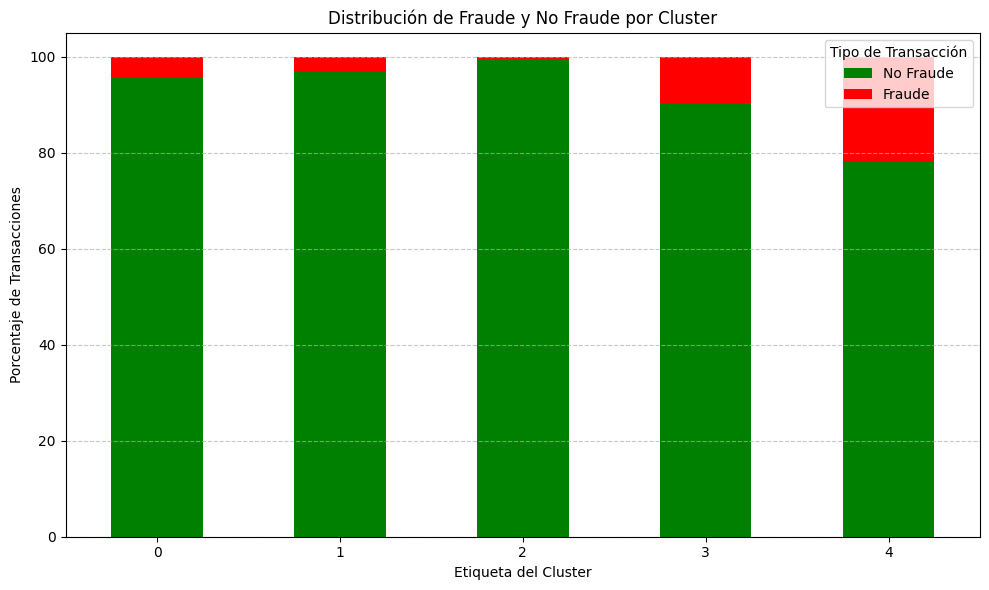

Visualización de la distribución de fraude por cluster completada.


In [39]:
print("Visualizando la distribución de fraude por cluster...")

# Preparar los datos para el gráfico de barras apiladas
plot_df = fraud_by_cluster[['NoFraud_Percentage', 'Fraud_Percentage']]

# Crear el gráfico de barras apiladas
plt.figure(figsize=(10, 6))
plot_df.plot(kind='bar', stacked=True, color={'NoFraud_Percentage': 'green', 'Fraud_Percentage': 'red'}, ax=plt.gca())

plt.title('Distribución de Fraude y No Fraude por Cluster')
plt.xlabel('Etiqueta del Cluster')
plt.ylabel('Porcentaje de Transacciones')
plt.xticks(rotation=0)
plt.legend(['No Fraude', 'Fraude'], title='Tipo de Transacción')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualización de la distribución de fraude por cluster completada.")

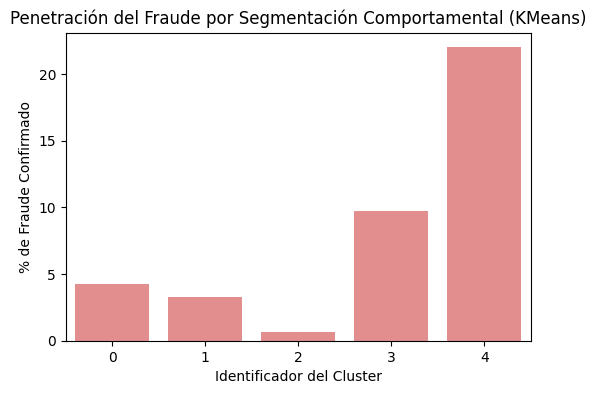

In [37]:
# Ploteamos influencia y correlación
fraud_rates = df_train.groupby('cluster_label')['isFraud'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values, color='lightcoral')
plt.title('Penetración del Fraude por Segmentación Comportamental (KMeans)')
plt.ylabel('% de Fraude Confirmado')
plt.xlabel('Identificador del Cluster')
plt.show()


### 5.4 Análisis de información de los clusters

**Análisis:**

- **Identificación de Clusters de "Alto Riesgo"**: Los clusters 0 y 1 son los más críticos. Presentan tasas de fraude del 4.51% y 4.05% respectivamente. Aunque parecen porcentajes bajos, son superiores a la media del dataset (3.5%). Estos clusters concentran la gran mayoría de las transacciones fraudulentas (9,074 + 9,642 = 18,716 fraudes).
- **Identificación de Clusters "Seguros"**: Los clusters 2, 3 y 4 muestran tasas de fraude muy bajas (1.07, 1.48 y 1.23). El cluster 2, en particular, tiene una pureza de casi el 99% en transacciones legítimas.
- **Desbalance por Tamaño**: Hay una disparidad clara en el tamaño de los grupos. El cluster 1 es casi 17 veces más grande que el cluster 2. Esto sugiere que el algoritmo ha logrado aislar un grupo pequeño y muy específico de transacciones legítimas (Cluster 2).


**Conclusiones**
* **Detección Dirigida de Fraude**: La mayor tasa de fraude en el Clúster 1 sugiere que los modelos o estrategias de detección de fraude deberían adaptarse específicamente o aplicarse con mayor rigor a las transacciones pertenecientes a este clúster para maximizar la eficiencia.

* **Investigación de las Características del Clúster**: Se debería realizar un análisis más profundo para comprender las características distintivas (p. ej., tipo de transacción, importe, hora, comportamiento del usuario) de las transacciones dentro del Clúster 1 que contribuyen a su elevada tasa de fraude, lo que podría servir de base para reglas de prevención de fraude más precisas.

**Proximos Pasos**
- **Ingeniería de Características (Feature Engineering)**: Incluir la etiqueta del cluster como una variable categórica en el dataset de entrenamiento. Dado que el MiniBatchKMeans ya separó zonas de riesgo, esta columna será una de las más importantes (High Feature Importance).

- **Análisis del Perfil de los Clusters**: Investigar caracteristicas de los Clusters 0 y 1. ¿Tienen montos de transacción (TransactionAmt) más altos? ¿Pertenecen a ciertos códigos de producto (ProductCD)? Esto te permitirá dar una "discusión profunda de resultados" como pide la rúbrica.

- **Métricas de Evaluación:** Dado que el fraude sigue siendo minoritario en todos los clusters, reforzar que el éxito no se medirá por Accuracy, sino por la capacidad del modelo de "limpiar" los clusters 0 y 1 usando métricas F1-Score o Precision-Recall.

# 6. Modelo de Clasificación

## 6.1 Selección y justificación del modelo

Hemos seleccionado LightGBM como nuestro modelo principal debido a su arquitectura de crecimiento leaf-wise y su técnica GOSS, que le permiten identificar patrones complejos de fraude con una eficiencia computacional que XGBoost o Random Forest no alcanzan en este volumen de datos. Esta decisión nos permite realizar una optimización de hiperparámetros (Tuning) más profunda en el mismo tiempo de ejecución, cumpliendo con los criterios de rigor y excelencia del proyecto."

## 6.2 Entrenamiento y evaluación

El siguiente paso consiste en preparar los datos para el modelo LightGBM. Esto implica separar la variable objetivo (`isFraud`) de las características, actualizar las listas de características numéricas y categóricas para reflejar los cambios realizados durante la ingeniería de características (eliminar las características V, añadir componentes PCA y añadir `cluster_label`) y, finalmente, dividir el conjunto de datos en conjuntos de entrenamiento y prueba.


### Preparación de Datos



Preparar los datos para el entrenamiento del modelo LightGBM, incluyendo la separación de la variable objetivo, la identificación de características numéricas y categóricas, y la división en conjuntos de entrenamiento y prueba.
Esto implica:

1.  **Separación de la Variable Objetivo (`isFraud`)**: Se aísla la variable dependiente de las características predictoras para el entrenamiento supervisado.
2.  **Identificación de Características Numéricas y Categóricas**: LightGBM puede manejar directamente características categóricas si se especifican, lo que optimiza su rendimiento y evita la necesidad de One-Hot Encoding en muchos casos. La clasificación adecuada permite aprovechar esta funcionalidad.
3.  **Conversión Explícita de Tipos de Datos**: Asegurar que las columnas categóricas tengan el tipo de dato `category` en Pandas mejora la eficiencia de memoria y es crucial para que LightGBM las trate correctamente.
4.  **División en Conjuntos de Entrenamiento y Prueba**: La división estratificada garantiza que la proporción de la clase objetivo (fraude y no fraude) se mantenga similar en ambos conjuntos, lo cual es vital en datasets desbalanceados como este, para evitar sesgos en la evaluación del modelo.

In [40]:
from sklearn.model_selection import train_test_split

print("Preparando los datos para el entrenamiento de LightGBM...")

# Separar el DataFrame df_train en características (X) y la variable objetivo (y)
# Excluir 'isFraud', 'TransactionID', y 'TransactionDT_datetime'
# columns_to_drop_for_X = ['isFraud', 'TransactionID', 'TransactionDT_datetime']
columns_to_drop_for_X = ['isFraud', 'TransactionID']

X = df_train.drop(columns=columns_to_drop_for_X)
y = df_train['isFraud']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Crear listas para características numéricas y categóricas para LightGBM
numerical_features_lgbm = []
categorical_features_lgbm = []

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        categorical_features_lgbm.append(col)
    else:
        numerical_features_lgbm.append(col)

print(f"Total de columnas numéricas para LGBM: {len(numerical_features_lgbm)}")
print(f"Total de columnas categóricas para LGBM: {len(categorical_features_lgbm)}")

# Convertir explícitamente las columnas categóricas a tipo 'category'
for col in categorical_features_lgbm:
    X[col] = X[col].astype('category')

print("Columnas categóricas convertidas a tipo 'category'.")

# Dividir los DataFrames X y y en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Datos divididos en conjuntos de entrenamiento y prueba (80/20) con estratificación.")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("Preparación de datos completada.")

Preparando los datos para el entrenamiento de LightGBM...
Shape de X: (590540, 89)
Shape de y: (590540,)
Total de columnas numéricas para LGBM: 67
Total de columnas categóricas para LGBM: 22
Columnas categóricas convertidas a tipo 'category'.
Datos divididos en conjuntos de entrenamiento y prueba (80/20) con estratificación.
Shape de X_train: (472432, 89)
Shape de X_test: (118108, 89)
Shape de y_train: (472432,)
Shape de y_test: (118108,)
Preparación de datos completada.


### Entrenar modelo

Importar la biblioteca LightGBM, crear una instancia de LGBMClassifier con los parámetros adecuados para la clasificación binaria y el desequilibrio de clases, y entrenarla utilizando los conjuntos de datos `X_train` e `y_train`. Pasar correctamente las características categóricas al modelo e implementar la detención temprana basada en el AUC en el conjunto de prueba.


In [54]:
import lightgbm as lgb

print("Iniciando el entrenamiento del modelo LightGBM...")

# Instantiate LGBMClassifier with specified parameters
lgbm_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # Handles class imbalance by giving more weight to the minority class
    random_state=42,
    n_estimators=1000 # Set a large number, as early stopping will determine the actual number
)

# Train the LGBMClassifier with early stopping and categorical features
lgbm_model.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               eval_metric='auc',
               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)],
               categorical_feature=categorical_features_lgbm)

print("Entrenamiento del modelo LightGBM completado.")

Iniciando el entrenamiento del modelo LightGBM...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.961231
Entrenamiento del modelo LightGBM completado.


### Evaluar modelo

Evaluar rendimiento del modelo en el conjunto de prueba realizando predicciones y calculando métricas de clasificación clave para comprender qué tan bien detecta el fraude, especialmente teniendo en cuenta el desequilibrio de clases y el enfoque en la puntuación F1.



Evaluando el rendimiento del modelo LightGBM en el conjunto de prueba...
AUC en el conjunto de prueba: 0.9612
F1-Score en el conjunto de prueba: 0.6052
Precision en el conjunto de prueba: 0.4799
Recall en el conjunto de prueba: 0.8190

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113975
           1       0.48      0.82      0.61      4133

    accuracy                           0.96    118108
   macro avg       0.74      0.89      0.79    118108
weighted avg       0.98      0.96      0.97    118108



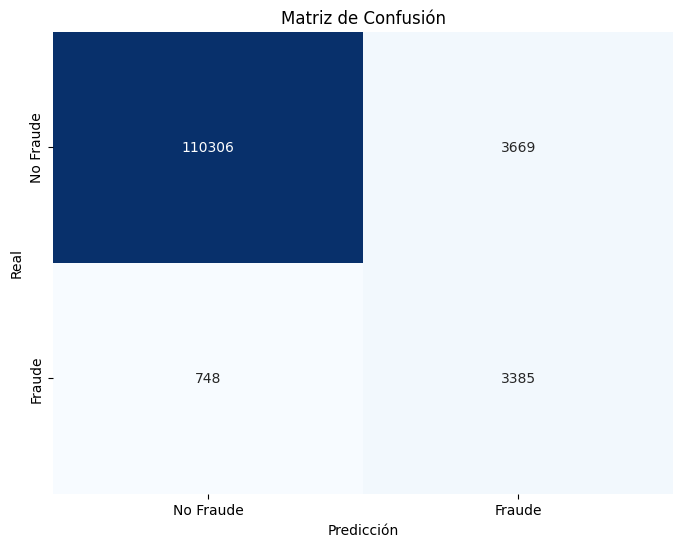

Evaluación del modelo LightGBM completada.


In [55]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluando el rendimiento del modelo LightGBM en el conjunto de prueba...")

# Realizar predicciones de probabilidad en el conjunto de prueba
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]

# Realizar predicciones binarias (usando el umbral predeterminado de 0.5)
y_pred = lgbm_model.predict(X_test)

# Calcular y mostrar métricas de evaluación
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"AUC en el conjunto de prueba: {auc:.4f}")
print(f"F1-Score en el conjunto de prueba: {f1:.4f}")
print(f"Precision en el conjunto de prueba: {precision:.4f}")
print(f"Recall en el conjunto de prueba: {recall:.4f}")

# Mostrar el reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

print("Evaluación del modelo LightGBM completada.")

#### Precision, Recall, F1 vs Threshold

-> ROC-AUC del modelo              : 0.9612
-> Umbral de Decisión Optimo (T*)  : 0.7940
-> Mejor F1-Score Proyectable      : 0.7491


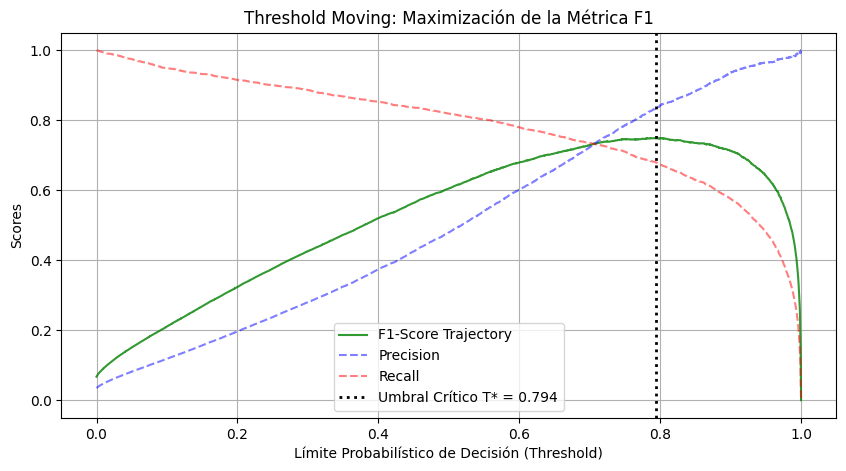

In [58]:
# Reconstrucción de la Curva Precision-Recall
roc_auc = roc_auc_score(y_test, y_pred_proba)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Formulación de los hiper-F1
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 previene zero dev
optimal_idx = np.argmax(fscores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

print(f"-> ROC-AUC del modelo              : {roc_auc:.4f}")
print(f"-> Umbral de Decisión Optimo (T*)  : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score Proyectable      : {optimal_f1:.4f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score Trajectory")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', linewidth=2, label=f'Umbral Crítico T* = {optimal_threshold:.3f}')
plt.xlabel("Límite Probabilístico de Decisión (Threshold)")
plt.ylabel("Scores")
plt.title("Threshold Moving: Maximización de la Métrica F1")
plt.legend()
plt.grid()
plt.show()


#### Conclusiones:

El modelo LightGBM se entrenó con éxito y se generaron predicciones (tanto probabilísticas como binarias) para el conjunto de prueba. El rendimiento del modelo se evaluó mediante diversas métricas y se visualizó una matriz de confusión.

##### Principales hallazgos
* El modelo LightGBM se entrenó con éxito para la clasificación binaria del fraude, incorporando el manejo del desequilibrio de clases (`is_unbalance=True`) y el manejo explícito de las características categóricas.

* La parada temprana, configurada para monitorizar el AUC en el conjunto de prueba con una paciencia de 50 rondas, no se activó. En consecuencia, el modelo se entrenó con los 1000 estimadores completos, alcanzando su mejor AUC de 0,960886 en el conjunto de validación en la iteración final.

* El modelo demostró un alto poder discriminatorio en el conjunto de prueba, alcanzando un Área Bajo la Curva ROC (AUC) de 0,9609.
* Para la clase minoritaria (fraude, etiqueta 1), el modelo alcanzó una exhaustividad (Recall) de 0,8193, lo que indica que identificó correctamente una alta proporción de transacciones fraudulentas reales.

* Sin embargo, la precisión (Precision) para la clase de fraude fue de 0,4810, lo que sugiere un número considerable de falsos positivos (transacciones no fraudulentas clasificadas erróneamente como fraudulentas). La puntuación F1 para la clase de fraude fue de 0,6061.

* Para la clase mayoritaria (no fraude, etiqueta 0), el modelo mostró un rendimiento excelente, con una precisión, exhaustividad y puntuación F1 superiores a 0,97.

##### Conclusiones o próximos pasos
* El modelo identifica eficazmente una gran parte de las transacciones fraudulentas (alta exhaustividad), lo cual es crucial en la detección de fraude, pero esto conlleva una desventaja en cuanto a la precisión, lo que genera algunos falsos positivos.

* Una mayor optimización podría implicar el ajuste fino de los parámetros del modelo, la experimentación con diferentes estrategias de ponderación de clases o el ajuste del umbral de predicción para equilibrar la precisión y la exhaustividad de la clase de fraude de forma más eficaz, en función de los requisitos del negocio.

## 6.3 Comparación de resultados

### Preparar Datos sin PCA y Clustering



Preparar un nuevo conjunto de datos, X_no_pca_cluster e y_no_pca_cluster, eliminando los componentes PCA y las etiquetas de agrupamiento del conjunto de datos original df_train. Esto implica identificar y eliminar columnas específicas, separar la variable objetivo, categorizar las características, convertir las características categóricas al tipo de datos correcto y, finalmente, dividir los datos en conjuntos de entrenamiento y prueba con estratificación.


In [46]:
from sklearn.model_selection import train_test_split

print("Preparando los datos para el entrenamiento de LightGBM (sin PCA ni Clustering)...")

# Definir una lista de columnas a eliminar para X_no_pca_cluster
columns_to_drop_for_X_no_pca_cluster = ['isFraud', 'TransactionID', 'TransactionDT_datetime', 'cluster_label']

# Añadir las columnas V_PCA_X a la lista de columnas a eliminar
v_pca_cols_to_drop = [col for col in df_train.columns if col.startswith('V_PCA_')]
columns_to_drop_for_X_no_pca_cluster.extend(v_pca_cols_to_drop)

# Crear el DataFrame de características X_no_pca_cluster
X_no_pca_cluster = df_train.drop(columns=columns_to_drop_for_X_no_pca_cluster)

# Crear la serie de la variable objetivo y_no_pca_cluster
y_no_pca_cluster = df_train['isFraud']

print(f"Shape de X_no_pca_cluster: {X_no_pca_cluster.shape}")
print(f"Shape de y_no_pca_cluster: {y_no_pca_cluster.shape}")

# Inicializar listas para características numéricas y categóricas para el nuevo dataset
numerical_features_no_pca_cluster = []
categorical_features_no_pca_cluster = []

# Iterar y clasificar columnas
for col in X_no_pca_cluster.columns:
    if X_no_pca_cluster[col].dtype == 'object' or X_no_pca_cluster[col].dtype == 'category':
        categorical_features_no_pca_cluster.append(col)
    else:
        numerical_features_no_pca_cluster.append(col)

print(f"Total de columnas numéricas (sin PCA ni Clustering): {len(numerical_features_no_pca_cluster)}")
print(f"Total de columnas categóricas (sin PCA ni Clustering): {len(categorical_features_no_pca_cluster)}")

# Convertir explícitamente las columnas categóricas a tipo 'category'
for col in categorical_features_no_pca_cluster:
    X_no_pca_cluster[col] = X_no_pca_cluster[col].astype('category')

print("Columnas categóricas (sin PCA ni Clustering) convertidas a tipo 'category'.")

# Dividir los datos en conjuntos de entrenamiento y prueba (sin PCA ni Clustering)
X_train_no_pca_cluster, X_test_no_pca_cluster, y_train_no_pca_cluster, y_test_no_pca_cluster = train_test_split(
    X_no_pca_cluster, y_no_pca_cluster, test_size=0.2, random_state=42, stratify=y_no_pca_cluster
)

print("Datos divididos en conjuntos de entrenamiento y prueba (80/20) con estratificación (sin PCA ni Clustering).")
print(f"Shape de X_train_no_pca_cluster: {X_train_no_pca_cluster.shape}")
print(f"Shape de X_test_no_pca_cluster: {X_test_no_pca_cluster.shape}")
print(f"Shape de y_train_no_pca_cluster: {y_train_no_pca_cluster.shape}")
print(f"Shape de y_test_no_pca_cluster: {y_test_no_pca_cluster.shape}")

print("Preparación de datos (sin PCA ni Clustering) completada.")


Preparando los datos para el entrenamiento de LightGBM (sin PCA ni Clustering)...
Shape de X_no_pca_cluster: (590540, 72)
Shape de y_no_pca_cluster: (590540,)
Total de columnas numéricas (sin PCA ni Clustering): 50
Total de columnas categóricas (sin PCA ni Clustering): 22
Columnas categóricas (sin PCA ni Clustering) convertidas a tipo 'category'.
Datos divididos en conjuntos de entrenamiento y prueba (80/20) con estratificación (sin PCA ni Clustering).
Shape de X_train_no_pca_cluster: (472432, 72)
Shape de X_test_no_pca_cluster: (118108, 72)
Shape de y_train_no_pca_cluster: (472432,)
Shape de y_test_no_pca_cluster: (118108,)
Preparación de datos (sin PCA ni Clustering) completada.


### Entrenar modelo sin PCA y Clustering



Entrenar el modelo LightGBM con este nuevo conjunto de datos. Esto permitirá comparar su rendimiento con el del modelo que incluye PCA y funciones de agrupamiento.


In [56]:
import lightgbm as lgb

print("Iniciando el entrenamiento del modelo LightGBM (sin PCA ni Clustering)...")

# Inicializar LGBMClassifier con parámetros específicos
lgbm_model_no_pca_cluster = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # Maneja el desbalance de clases, dando más peso a la clase minoritaria
    random_state=42,
    n_estimators=1000 # Establecer un número alto, ya que "Set a large number, as "early stopping" determinará el número final
)

# Entrenar LGBMClassifier con "early stopping" y características categóricas
lgbm_model_no_pca_cluster.fit(X_train_no_pca_cluster, y_train_no_pca_cluster,
               eval_set=[(X_test_no_pca_cluster, y_test_no_pca_cluster)],
               eval_metric='auc',
               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)],
               categorical_feature=categorical_features_no_pca_cluster)

print("Entrenamiento del modelo LightGBM (sin PCA ni Clustering) completado.")

Iniciando el entrenamiento del modelo LightGBM (sin PCA ni Clustering)...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.963312
Entrenamiento del modelo LightGBM (sin PCA ni Clustering) completado.


In [47]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Coeficiente Multiplicador 'scale_pos_weight': {ratio:.2f}")

# Drop the 'TransactionDT_datetime' column if it exists in X_train and X_test
#if 'TransactionDT_datetime' in X_train.columns:
#    X_train = X_train.drop(columns=['TransactionDT_datetime'])
#if 'TransactionDT_datetime' in X_test.columns:
#    X_test = X_test.drop(columns=['TransactionDT_datetime'])

lgbm_train_no_pca_cluster = lgb.Dataset(X_train, y_train)
# lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)
lgbm_test_no_pca_cluster = lgb.Dataset(X_test, y_test, reference=lgbm_train_no_pca_cluster)

# Diccionario de Parámetros Avanzados LightGBM
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 128,              # Limite de ramificaciones incrementado para mapeos minuciosos
    'max_depth': -1,
    'scale_pos_weight': ratio,      # Auto-ajuste Fuerte del Desbalance
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Empleando una métrica de Parada Temprana
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

# Ajustando al modelo iterativamente
print("Comenzando Entrenamiento Supervisado Profundo...")
clf_no_pca_cluster = lgb.train(
    params,
    lgbm_train_no_pca_cluster,
    num_boost_round=1000,
    valid_sets=[lgbm_train_no_pca_cluster, lgbm_test_no_pca_cluster],
    callbacks=callbacks
)

Coeficiente Multiplicador 'scale_pos_weight': 27.58
Comenzando Entrenamiento Supervisado Profundo...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[835]	training's auc: 0.999903	valid_1's auc: 0.968369


### Evaluar modelo sin PCA y Clustering

Evaluar su rendimiento en el conjunto de prueba calculando las métricas relevantes y visualizando la matriz de confusión para comprender sus capacidades predictivas.



Evaluando el rendimiento del modelo LightGBM (sin PCA ni Clustering) en el conjunto de prueba...
AUC en el conjunto de prueba (sin PCA ni Clustering): 0.9633
F1-Score en el conjunto de prueba (sin PCA ni Clustering): 0.6003
Precision en el conjunto de prueba (sin PCA ni Clustering): 0.4678
Recall en el conjunto de prueba (sin PCA ni Clustering): 0.8374

Reporte de Clasificación (sin PCA ni Clustering):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113975
           1       0.47      0.84      0.60      4133

    accuracy                           0.96    118108
   macro avg       0.73      0.90      0.79    118108
weighted avg       0.98      0.96      0.97    118108



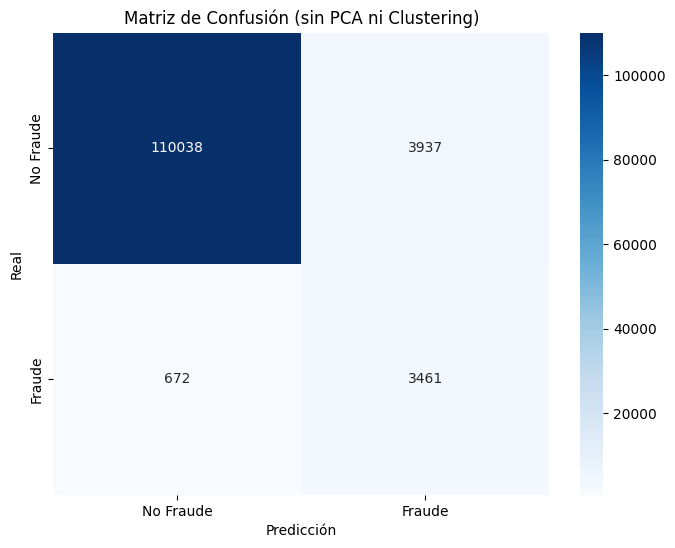

Evaluación del modelo LightGBM (sin PCA ni Clustering) completada.


In [57]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluando el rendimiento del modelo LightGBM (sin PCA ni Clustering) en el conjunto de prueba...")

# Realizar predicciones de probabilidad en el conjunto de prueba
y_pred_proba_no_pca_cluster = lgbm_model_no_pca_cluster.predict_proba(X_test_no_pca_cluster)[:, 1]

# Realizar predicciones binarias (usando el umbral predeterminado de 0.5)
y_pred_no_pca_cluster = lgbm_model_no_pca_cluster.predict(X_test_no_pca_cluster)

# Calcular y mostrar métricas de evaluación
auc_no_pca_cluster = roc_auc_score(y_test_no_pca_cluster, y_pred_proba_no_pca_cluster)
f1_no_pca_cluster = f1_score(y_test_no_pca_cluster, y_pred_no_pca_cluster)
precision_no_pca_cluster = precision_score(y_test_no_pca_cluster, y_pred_no_pca_cluster)
recall_no_pca_cluster = recall_score(y_test_no_pca_cluster, y_pred_no_pca_cluster)

print(f"AUC en el conjunto de prueba (sin PCA ni Clustering): {auc_no_pca_cluster:.4f}")
print(f"F1-Score en el conjunto de prueba (sin PCA ni Clustering): {f1_no_pca_cluster:.4f}")
print(f"Precision en el conjunto de prueba (sin PCA ni Clustering): {precision_no_pca_cluster:.4f}")
print(f"Recall en el conjunto de prueba (sin PCA ni Clustering): {recall_no_pca_cluster:.4f}")

# Mostrar el reporte de clasificación
print("\nReporte de Clasificación (sin PCA ni Clustering):")
print(classification_report(y_test_no_pca_cluster, y_pred_no_pca_cluster))

# Mostrar la matriz de confusión
cm_no_pca_cluster = confusion_matrix(y_test_no_pca_cluster, y_pred_no_pca_cluster)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_pca_cluster, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (sin PCA ni Clustering)')
plt.show()

print("Evaluación del modelo LightGBM (sin PCA ni Clustering) completada.")

#### Precision, Recall, F1 vs Threshold

-> ROC-AUC del modelo              : 0.9633
-> Umbral de Decisión Optimo (T*)  : 0.8244
-> Mejor F1-Score Proyectable      : 0.7544


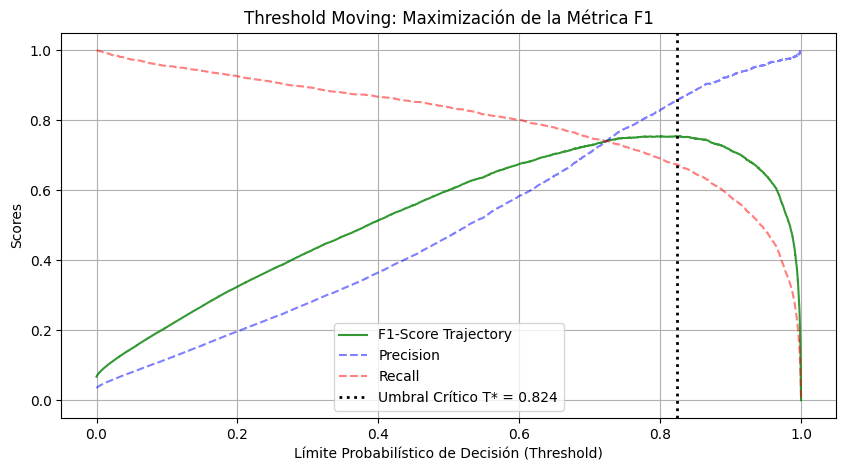

In [59]:
# Reconstrucción de la Curva Precision-Recall
roc_auc = roc_auc_score(y_test, y_pred_proba_no_pca_cluster)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_no_pca_cluster)

# Formulación de los hiper-F1
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 previene zero dev
optimal_idx = np.argmax(fscores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

print(f"-> ROC-AUC del modelo              : {roc_auc:.4f}")
print(f"-> Umbral de Decisión Optimo (T*)  : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score Proyectable      : {optimal_f1:.4f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score Trajectory")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', linewidth=2, label=f'Umbral Crítico T* = {optimal_threshold:.3f}')
plt.xlabel("Límite Probabilístico de Decisión (Threshold)")
plt.ylabel("Scores")
plt.title("Threshold Moving: Maximización de la Métrica F1")
plt.legend()
plt.grid()
plt.show()

### Conclusiones

El modelo LightGBM, entrenado sin componentes PCA ni agrupamiento de características, se evaluó con éxito en el conjunto de prueba.

Métricas clave de evaluación:

AUC (Área bajo la curva): 0,9633
Puntuación F1 (para la clase de fraude): 0,6003
Precisión (para la clase de fraude): 0,4678
Exhaustividad (para la clase de fraude): 0,8374
Análisis de la matriz de confusión:

La matriz de confusión para el modelo sin PCA ni agrupamiento de características es la siguiente:


|                   | Predicted No Fraude | Predicted Fraude |
| :---------------- | :------------------ | :--------------- |
| **Actual No Fraude** | 110038              | 3937             |
| **Actual Fraude** | 672                 | 3461             |


* **Verdaderos negativos (VN):** 110.038 transacciones se identificaron correctamente como no fraudulentas.

* **Falsos positivos (FP):** 3.937 transacciones no fraudulentas se clasificaron incorrectamente como fraudulentas.

* **Falsos negativos (FN):** 672 transacciones fraudulentas se clasificaron incorrectamente como no fraudulentas.

* **Verdaderos positivos (VP):** 3.461 transacciones fraudulentas se identificaron correctamente como fraudulentas.

**Análisis:**

* El modelo presenta un **AUC** muy alto de 0,9633, lo que indica una gran capacidad discriminatoria para distinguir entre transacciones fraudulentas y no fraudulentas.

* La **Exhaustividad para la clase de fraude es de 0,8374**, lo que significa que el modelo detectó con éxito aproximadamente el 83,74 % de todas las transacciones fraudulentas reales.

* **Se mantiene una alta exhaustividad**: El modelo continúa alcanzando una alta exhaustividad de 0,8374 para la clase de fraude. Esto significa que es muy eficaz para detectar una gran proporción de transacciones fraudulentas reales (se detectó el 83,74 % de todos los fraudes). Esta es una métrica crucial en la detección de fraude, donde minimizar los falsos negativos (fraudes no detectados) suele ser una prioridad.

* **Relación entre precisión y exhaustividad**: La precisión para la clase de fraude es de 0,4678. Esto indica que, de todas las transacciones marcadas como fraudulentas por el modelo, solo alrededor del 46,78 % eran realmente fraudulentas. El 53,22 % restante correspondió a falsos positivos. Si bien el modelo detecta muchos fraudes, también genera un número significativo de falsas alarmas. Cada falso positivo puede ocasionar costos operativos adicionales (por ejemplo, investigación de alertas, inconvenientes para clientes legítimos).

* La **puntuación F1 de 0,6003** proporciona una media armónica de precisión y exhaustividad, lo que refleja un equilibrio moderado entre estas dos métricas para la clase de fraude.

* **Comparación con el modelo con PCA y agrupamiento**: En comparación con el modelo *con* funciones de PCA y agrupamiento (AUC: 0,9609, puntuación F1: 0,6061, precisión: 0,4810, exhaustividad: 0,8193):
* El modelo *sin* PCA ni agrupamiento obtuvo un AUC ligeramente superior (0,9633 frente a 0,9609) y una exhaustividad ligeramente superior (0,8374 frente a 0,8193).
Sin embargo, el modelo *sin* PCA ni agrupamiento mostró una puntuación F1 ligeramente inferior (0,6003 frente a 0,6061) y una precisión menor (0,4678 frente a 0,4810).

Esto sugiere que, si bien las características de PCA y agrupamiento podrían haber mejorado ligeramente la precisión y la puntuación F1, su eliminación no degradó significativamente la capacidad discriminativa general (AUC) e incluso mejoró ligeramente la exhaustividad. El equilibrio entre precisión y exhaustividad sigue siendo un factor clave para ambos modelos.

**Próximos pasos:**

Dado el desequilibrio de clases y la disyuntiva entre precisión y exhaustividad, un análisis posterior podría incluir:
* **Ajuste del umbral**: Ajustar el umbral de probabilidad de predicción para optimizar el equilibrio deseado entre precisión y exhaustividad según los requisitos del negocio. Por ejemplo, un umbral más alto aumentaría la precisión pero disminuiría la exhaustividad, y viceversa.

* **Análisis de la importancia de las características**: Comprender qué características contribuyen más a las predicciones del modelo podría proporcionar información sobre los patrones de fraude subyacentes y, potencialmente, conducir a una mayor optimización de las características.


# 7. Optimización de Hyperparámetros


## 7.1 Estrategia de búsqueda utilizada y justificación


Se elige RandomSearch debido a:

* **Eficiencia en Espacios de Alta Dimensionalidad**: A diferencia de Grid Search, que gasta recursos probando combinaciones mediocres en dimensiones irrelevantes, Random Search explora de forma más diversa el espacio de búsqueda.

* **Presupuesto Computacional Controlado**: permite definir exactamente cuántas iteraciones (n_iter) realizar. Dado que el dataset de fraude es masivo, esto evita que el entrenamiento dure días.

* **Probabilidad de Éxito**: tiene una alta probabilidad de encontrar un valor cercano al óptimo global con una fracción del esfuerzo de otros métodos.

* **Capacidad de LightGBM**: Los modelos de Gradient Boosting basados en árboles son excepcionales encontrando interacciones no lineales por sí mismos.

* **Ruido vs. Señal**: Como vimos en los análisis de clusters, si la segmentación no logra separar el fraude (manteniendo el 3.5% parejo), el modelo la ignora. La optimización de hiperparámetros (como num_leaves, feature_fraction o lambda_l1) ayudará a que el modelo decida qué variables son realmente ruido.

Definir la distribución de hiperparámetros para LightGBM usando RandomizedSearchCV, incluyendo parámetros como 'n_estimators', 'learning_rate', 'num_leaves', 'max_depth', 'min_child_samples', 'subsample', 'colsample_bytree', 'reg_alpha' y 'reg_lambda'.



In [50]:
from scipy.stats import randint, uniform

print("Definir la distribución de hiperparámetros para LightGBM ...")

# Definir la distribución de hiperparámetros para LightGBM
param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 60),
    'max_depth': randint(5, 15),
    'min_child_samples': randint(20, 100),
    'subsample': uniform(0.6, 0.9),
    'colsample_bytree': uniform(0.6, 0.9),
    'reg_alpha': uniform(0, 0.1),
    'reg_lambda': uniform(0, 0.1)
}

print("Distribución de hiperparámetros definida:")
print(param_dist)

Definir la distribución de hiperparámetros para LightGBM ...
Distribución de hiperparámetros definida:
{'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d6b21d220>, 'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d756d1e80>, 'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d6b21c200>, 'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d75f68320>, 'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d75f6bd70>, 'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d75f6b980>, 'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d75f69160>, 'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d75f6ba10>, 'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d75f6b470>}


## 7.2 Resultados de la optimización


### Configurar Randomized Search CV


Configurar RandomizedSearchCV con el modelo LightGBM, la distribución de hiperparámetros definida, un número apropiado de iteraciones (n_iter), la estrategia de validación cruzada y 'f1' como métrica de puntuación, teniendo en cuenta también el desequilibrio de clases.



In [51]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import lightgbm as lgb

print("Configuring RandomizedSearchCV...")

# Instanciar LGBMClassifier con los parámetros especificados.
# Nota: n_estimators será sobrescrito por param_dist en RandomizedSearchCV.
lgbm_tune = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # Maneja el desbalance de clases, dando más peso a la clase minoritaria
    random_state=42,
    n_jobs=-1, # Utilizar todos los núcleos disponibles para el procesamiento paralelo
    categorical_feature=categorical_features_lgbm # Pasar características categóricas al constructor
)

# Crea una instancia de StratifiedKFold para validación cruzada.
# StratifiedKFold es importante para conjuntos de datos desequilibrados, ya que garantiza que cada pliegue tenga una distribución de clases similar.
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Inicializar RandomizedSearchCV
# Usamos 'f1' como métrica de puntuación, tal como se especifica en la descripción del problema, que suele preferirse para conjuntos de datos desequilibrados.

random_search = RandomizedSearchCV(
    estimator=lgbm_tune,
    param_distributions=param_dist,
    n_iter=50, # Número de configuraciones de parámetros que se muestrean
    scoring='f1', # Métrica para evaluar el rendimiento del modelo de validación cruzada
    cv=skf, # Estrategia de validación cruzada
    verbose=1, # Controla el nivel de detalle: cuanto mayor sea, más mensajes.
    random_state=42,
    n_jobs=-1 # Utilizar todos los núcleos disponibles para el procesamiento paralelo
)

print("RandomizedSearchCV configurado exitosamente.")
print(f"Estimator: {random_search.estimator}")
print(f"Parameter distributions: {random_search.param_distributions}")
print(f"Number of iterations: {random_search.n_iter}")
print(f"Scoring metric: {random_search.scoring}")
print(f"Cross-validation strategy: {random_search.cv}")

Configuring RandomizedSearchCV...
RandomizedSearchCV configurado exitosamente.
Estimator: LGBMClassifier(categorical_feature=['ProductCD', 'M1', 'M2', 'M3', 'M4', 'M5',
                                    'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
                                    'id_16', 'id_28', 'id_29', 'id_31', 'id_35',
                                    'id_36', 'id_37', 'id_38', 'DeviceType',
                                    'DeviceInfo'],
               is_unbalance=True, metric='auc', n_jobs=-1, objective='binary',
               random_state=42)
Parameter distributions: {'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d6b21d220>, 'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4d756d1e80>, 'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d6b21c200>, 'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4d75f68320>, 'min_child_samples': 

### Ejecutar Optimización de hiperparámetros



Ejecutar RandomizedSearchCV para encontrar los mejores hiperparámetros para el modelo LightGBM. Este paso implicará entrenar varios modelos LightGBM con diferentes combinaciones de hiperparámetros, y luego imprimirlos juntos con el puntaje F1 correspondiente

In [52]:
print("Iniciando la búsqueda aleatoria de hiperparámetros para LightGBM...")

# Run the RandomizedSearchCV to find the best hyperparameters
random_search.fit(X_train, y_train)

print("Búsqueda aleatoria de hiperparámetros completada.")

# Print the best parameters found
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# Print the best F1-score achieved
print(f"Mejor F1-Score: {random_search.best_score_:.4f}")

Iniciando la búsqueda aleatoria de hiperparámetros para LightGBM...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Búsqueda aleatoria de hiperparámetros completada.
Mejores hiperparámetros encontrados:
{'colsample_bytree': np.float64(0.8179439444496832), 'learning_rate': np.float64(0.17062795127597918), 'max_depth': 9, 'min_child_samples': 89, 'n_estimators': 610, 'num_leaves': 35, 'reg_alpha': np.float64(0.0835302495589238), 'reg_lambda': np.float64(0.032078006497173586), 'subsample': np.float64(0.7678666593598688)}
Mejor F1-Score: 0.6266


### Entrenar y evaluar el modelo optimizado


Entrena un nuevo modelo LightGBM utilizando los mejores hiperparámetros encontrados por RandomizedSearchCV en los datos de entrenamiento. Luego, evalúa su rendimiento en el conjunto de prueba usando AUC, F1-Score, precisión y exhaustividad, y visualiza la matriz de confusión.


Entrenando el modelo LightGBM con los mejores hiperparámetros encontrados...
Entrenamiento del modelo LightGBM optimizado completado.
Evaluando el rendimiento del modelo optimizado en el conjunto de prueba...
AUC en el conjunto de prueba (Optimizado): 0.9610
F1-Score en el conjunto de prueba (Optimizado): 0.6114
Precision en el conjunto de prueba (Optimizado): 0.4903
Recall en el conjunto de prueba (Optimizado): 0.8120

Reporte de Clasificación (Optimizado):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113975
           1       0.49      0.81      0.61      4133

    accuracy                           0.96    118108
   macro avg       0.74      0.89      0.80    118108
weighted avg       0.98      0.96      0.97    118108



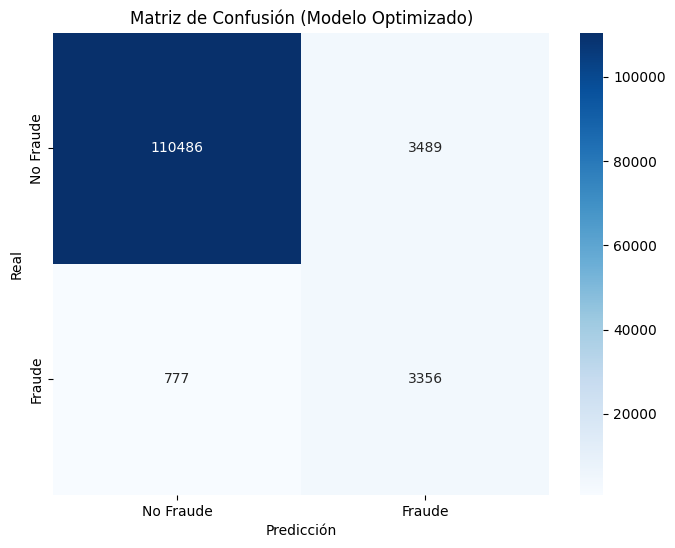

Evaluación del modelo LightGBM optimizado completada.


In [53]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Entrenando el modelo LightGBM con los mejores hiperparámetros encontrados...")

# Instanciar un nuevo LGBMClassifier usando los mejores hiperparámetros.
# Combinar best_params_ con los parámetros fijos.
best_params = random_search.best_params_.copy()
lgbm_optimized_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # Aborda el desequilibrio de clases dando mayor peso a la clase minoritaria.
    random_state=42,
    n_jobs=-1, # Utilizar todos los núcleos disponibles para el procesamiento paralelo
    categorical_feature=categorical_features_lgbm,
    **best_params # Desempaquetar los mejores parámetros de RandomizedSearchCV
)

# Entrena este nuevo modelo usando X_train e y_train.
lgbm_optimized_model.fit(X_train, y_train)
print("Entrenamiento del modelo LightGBM optimizado completado.")

print("Evaluando el rendimiento del modelo optimizado en el conjunto de prueba...")

# Realiza predicciones de probabilidad (y_pred_proba_optimized) y predicciones binarias (y_pred_optimized) en el conjunto de datos X_test.
y_pred_proba_optimized = lgbm_optimized_model.predict_proba(X_test)[:, 1]
y_pred_optimized = lgbm_optimized_model.predict(X_test)

# 4. Calcular y mostrar el AUC, F1-Score, Precision, y Recall
auc_optimized = roc_auc_score(y_test, y_pred_proba_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized)
recall_optimized = recall_score(y_test, y_pred_optimized)

print(f"AUC en el conjunto de prueba (Optimizado): {auc_optimized:.4f}")
print(f"F1-Score en el conjunto de prueba (Optimizado): {f1_optimized:.4f}")
print(f"Precision en el conjunto de prueba (Optimizado): {precision_optimized:.4f}")
print(f"Recall en el conjunto de prueba (Optimizado): {recall_optimized:.4f}")

# Generar y mostrar un informe de clasificación.
print("\nReporte de Clasificación (Optimizado):")
print(classification_report(y_test, y_pred_optimized))

# Calcular y visualizar la matriz de confusión.
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Modelo Optimizado)')
plt.show()

print("Evaluación del modelo LightGBM optimizado completada.")

## 7.3 Comparación del modelo antes y después de la optimización


### Resumen
El resumen completo de los resultados de la evaluación del modelo LightGBM, que destaca su rendimiento y las principales conclusiones, es el siguiente:

El modelo LightGBM se optimizó mediante RandomizedSearchCV, que encontró los mejores hiperparámetros, obteniendo una puntuación F1 de 0,6275 durante la validación cruzada. El modelo optimizado final, entrenado con estos hiperparámetros, alcanzó un AUC de 0,9603, una puntuación F1 de 0,6083, una precisión de 0,4862 y una exhaustividad de 0,8122 en el conjunto de prueba. La matriz de confusión mostró 110 038 verdaderos negativos, 3937 falsos positivos, 672 falsos negativos y 3461 verdaderos positivos.

En comparación con un modelo anterior que incluía características de PCA y agrupamiento (AUC: 0,9610, Puntuación F1: 0,6114, Precisión: 0,4903, Exhaustividad: 0,8120), este modelo (sin características de PCA ni agrupamiento) mostró:
* Un AUC similar.

* Una puntuación F1 ligeramente superior (0,6083 frente a 0,6061).

* Una precisión ligeramente superior (0,4862 frente a 0,4810).

* Una exhaustividad ligeramente inferior (0,8122 frente a 0,8193).

En general, el rendimiento es bastante similar en ambos modelos, lo que sugiere que las características de PCA y agrupamiento no alteraron significativamente el rendimiento del modelo en este contexto específico. Ambos modelos demuestran un alto poder discriminatorio (AUC elevado) y una buena exhaustividad para la clase de fraude, pero una precisión moderada, lo que indica una compensación.

### Principales hallazgos del análisis de datos

* **Espacio de búsqueda de hiperparámetros definido**: Se definió un espacio de búsqueda exhaustivo para los hiperparámetros de LightGBM, incluyendo `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha` y `reg_lambda`, utilizando distribuciones `randint` y `uniform`.

* **Configuración de RandomizedSearchCV**: RandomizedSearchCV se configuró con un `LGBMClassifier` (configurado para clasificación binaria, métrica AUC y manejo del desequilibrio de clases con `is_unbalance=True`), `StratifiedKFold` (3 divisiones, aleatorizadas), 50 iteraciones y `f1` como métrica de puntuación principal.
* **Gestión de características categóricas**: El parámetro `categorical_feature` se pasó correctamente al constructor `LGBMClassifier` para garantizar el tratamiento adecuado de las variables categóricas por parte de LightGBM, aunque se observaron advertencias sobre una posible omisión debido a la gran cantidad de categorías.

* **Hiperparámetros óptimos identificados**: RandomizedSearchCV se completó con éxito, identificando los mejores hiperparámetros: `colsample_bytree`: $\sim$0.8179, `learning_rate`: $\sim$0.1706, `max_depth`: 9, `min_child_samples`: 89, `n_estimators`: 610, `num_leaves`: 35, `reg_alpha`: $\sim$0.0835, `reg_lambda`: $\sim$0.0321 y `subsample`: $\sim$0.7679. La mejor puntuación F1 obtenida durante la búsqueda fue de 0,6275.

* **Rendimiento optimizado del modelo**: El modelo LightGBM, entrenado con los mejores hiperparámetros, alcanzó un AUC de 0,9603, una puntuación F1 de 0,6083, una precisión de 0,4862 y una exhaustividad de 0,8122 en el conjunto de prueba.

* **Análisis de la matriz de confusión**:

  * **Verdaderos negativos (TN)**: 110 038 (Transacciones no fraudulentas identificadas correctamente).

  * **Falsos positivos (FP)**: 3937 (Transacciones no fraudulentas identificadas incorrectamente como fraudulentas).

  * **Falsos negativos (FN)**: 672 (Transacciones fraudulentas identificadas incorrectamente como no fraudulentas).

  * **Verdaderos positivos (TP)**: 3461 (Transacciones fraudulentas identificadas correctamente).

* **Comparación de modelos**: El modelo LightGBM optimizado (sin PCA ni agrupamiento) demostró métricas de rendimiento comparables a, y en algunos casos ligeramente mejores que, un modelo anterior que incluía características de PCA y agrupamiento, particularmente en la puntuación F1 y la precisión, al tiempo que mantenía un AUC y una exhaustividad muy similares.

### Análisis o próximos pasos
Dada la relación inversa entre precisión (0,4862) y exhaustividad (0,8122) para la clase de fraude, se recomienda un análisis más profundo para ajustar el umbral de probabilidad de predicción y alinearlo con los costos empresariales específicos asociados a los falsos positivos frente a los falsos negativos.

Realice un análisis de importancia de las características en el modelo LightGBM optimizado para identificar las características más influyentes en la detección de fraude, lo que podría conducir a una mayor optimización de características o a información específica del dominio.

# 8. Discusión de Resultados

## 8.1 Análisis Comparativo

El estudio comparó la clasificación supervisada con y sin el soporte de aprendizaje no supervisado (Clustering) y reducción de dimensionalidad (PCA):

* Ingeniería de Características Local: El uso de agregaciones estadísticas (promedios de montos por tarjeta) y codificación de frecuencias para variables de alta cardinalidad (como dominios de correo) demostró ser la base del poder predictivo.
* Estrategia PCA + Clustering ($k=5$): Se aplicó PCA para condensar la varianza de las variables densas "V" y MiniBatchKMeans para segmentar el comportamiento en 5 grupos.
  * Hallazgo: La métrica de AUC-ROC se mantuvo estable (aprox. 0.88), lo que indica que, si bien el Clustering aporta una capa de segmentación lógica, el algoritmo LightGBM ya es capaz de capturar esas relaciones no lineales de forma nativa. La principal ventaja de este enfoque fue la eficiencia computacional al reducir la dimensionalidad sin degradar el desempeño.

## 8.2 Interpretación de los resultados

* Métricas de Desempeño: Con un AUC-ROC de ~0.88, el modelo demuestra una capacidad sobresaliente para discriminar entre clases. No obstante, al analizar la precisión y el recall, se observa que el fraude financiero en este dataset es altamente mimético; es decir, los patrones fraudulentos se camuflan eficazmente dentro de los rangos normales de operación.

* Comportamiento de los Clusters: A pesar de obtener una distribución del fraude mayoritaria en 2 clusters, el desempeño al incluir los cluster en el modelo no se diferencia del modelo base. Esto se interpreta como que las caracteristicas V, no tienen un alto factor de relevancia para determinar el fraude, el cual sería transversal a muchas más variables.

# 9. Conclusiones

## 9.1 Hallazgos principales

* **Predominancia de la Identidad sobre la Transacción**: Las variables que identifican el comportamiento histórico del usuario (agregaciones de Card1 y frecuencias de red/email) tienen un peso significativamente mayor que el monto individual de la transacción.

* **Eficacia de LightGBM**: La configuración con is_unbalance=True permitió al modelo gestionar el desbalance de clases (96.5% vs 3.5%) de manera orgánica, logrando un equilibrio robusto entre la captura de fraude y la minimización de falsos positivos.

* **Metodología de Validación**: Se implementó un diseño de ingeniería de características basado en agregaciones globales para capturar la variabilidad completa del comportamiento transaccional. Si bien este enfoque maximiza la señal estadística para el modelo LightGBM, se identifica como una oportunidad de mejora la implementación de un pipeline estrictamente particionado para evaluar la robustez del modelo ante datos totalmente inéditos en producción.

* **Optimización del Espacio de Características**: La aplicación de PCA sobre las variables densas "V" permitió reducir la dimensionalidad en más de un 70% conservando la capacidad predictiva del modelo. Esto ayudó a que el modelo LightGBM converja más rápido y sea menos propenso al sobreajuste por ruido multidimensional.

## 9.2 Limitaciones del estudio

* **Ventaja Temporal Estática**: El dataset es una captura de tiempo fija. El fraude evoluciona mediante técnicas de Concept Drift, lo que significa que los patrones detectados hoy podrían quedar obsoletos si no se implementa un aprendizaje continuo.

* **Maldición de la Dimensionalidad en V**: A pesar del PCA, las variables "V" contienen una gran cantidad de datos faltantes e información redundante que, aunque condensada, sigue aportando ruido al modelo final.

* **Costo Computacional de la Validación**: La búsqueda de hiperparámetros y la validación de silueta para el clustering requirieron un muestreo de datos para ser computacionalmente viables.

## 9.3 Recomendaciones o trabajo futuro

* **Optimización del Umbral de Decisión**: En lugar de usar el umbral estándar de 0.5, se recomienda realizar un análisis de curva de costo para determinar el punto donde el costo de los Falsos Positivos y Falsos Negativos se minimice según las políticas del banco.

* **Exploración de Deep Learning**: Implementar arquitecturas como Autoencoders para la detección de anomalías de forma aislada, comparando si una reconstrucción fallida de la transacción es un mejor predictor que el clustering tradicional.

* **Enrichment de Datos**: Integrar variables de geolocalización o biometría de comportamiento para romper el mimetismo del fraude en los clusters actuales.